# ln-history analysis

## Import

In [44]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import datetime as dt
import re
from scipy import stats
import os
import paramiko
if not hasattr(paramiko, 'DSSKey'):
    class DummyDSSKey: pass
    paramiko.DSSKey = DummyDSSKey # type: ignore
from sshtunnel import SSHTunnelForwarder
from cycler import cycler
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from dotenv import load_dotenv
from datetime import datetime
import json
from typing import Tuple
from pathlib import Path

# Load env variables 
load_dotenv(".env")

True

## Database connection
The credentials to the database are kept scret in the `.env` file.

In [10]:
def setup_secure_connection():
    """
    Creates an SSH Tunnel to the VPS and returns a configured SQLAlchemy Engine.
    """
    # 1. Configure the SSH Tunnel
    # We use local_bind_address=('127.0.0.1', 0) so the OS automatically assigns 
    # a free local port. This prevents "port already in use" errors if you run 
    # this cell multiple times.
    tunnel = SSHTunnelForwarder(
        (os.getenv('SSH_HOST'), 22),
        ssh_username=os.getenv('SSH_USER'),
        ssh_password=os.getenv('SSH_PASSWORD'),
        remote_bind_address=('127.0.0.1', 5432),  
        local_bind_address=('127.0.0.1', 0),     
        set_keepalive=60
    )
    
    # Start the tunnel
    tunnel.start()
    print(f"SSH Tunnel established. Local port mapped to: {tunnel.local_bind_port}")

    for key in ('SSH_HOST', 'SSH_USER', 'SSH_PASSWORD', 'POSTGRES_USER', 'POSTGRES_PASSWORD', 'POSTGRES_DBNAME'):
      if not os.getenv(key):                                                                                                                                 
          raise EnvironmentError(f"Missing required env variable: {key}") 

    # 2. Configure SQLAlchemy to use the tunnel's local port
    password = quote_plus(os.getenv("POSTGRES_PASSWORD"))
    user = os.getenv("POSTGRES_USER")
    dbname = os.getenv("POSTGRES_DBNAME")
    
    DB_CONNECTION = (
        f"postgresql+psycopg2://{user}:{password}"
        f"@127.0.0.1:{tunnel.local_bind_port}"
        f"/{dbname}"
    )
    
    engine = create_engine(DB_CONNECTION)
    print("Database engine configured securely through tunnel.")
    
    return engine, tunnel

# Initialize the connection
db_engine, ssh_tunnel = setup_secure_connection()

def run_query(sql):
    """
    Runs a SQL query using the SQLAlchemy engine.
    """
    return pd.read_sql(sql, db_engine)

SSH Tunnel established. Local port mapped to: 61681
Database engine configured securely through tunnel.


### Database schema
The database schema (in DBML format) can be found in the [root GitHub repository of the ln-history organisation](https://github.com/ln-history/.github/blob/main/db-schema.DBML)

## Helper Functions

In [11]:
def save_plot_for_latex(fig, file_name: str, file_path: str = "../resources/results"):
    """
    Saves a Matplotlib figure as a PDF, optimized for LaTeX.

    Args:
        fig (matplotlib.figure.Figure): The figure object to save.
        file_name (str): The name of the file without the extension
        file_path (str): The directory where the file should be saved (default: '/resources/results').
    """
    if not os.path.exists(file_path):
        os.makedirs(file_path)
        
    full_path = os.path.join(file_path, f"{file_name}-{dt.datetime.now().strftime("%Y-%m-%d_%H:%M:%S")}.pdf")

    if file_path == "../resources/results-final":
        full_path = os.path.join(file_path, f"{file_name}.pdf")
    
    fig.savefig(full_path, format='pdf', bbox_inches='tight')
    
    print(f"Plot saved to: {full_path}")

In [12]:
def format_date_range(start_str: str, end_str: str) -> str:
    start_dt = datetime.strptime(start_str, "%Y-%m-%dT%H:%M:%SZ")
    end_dt = datetime.strptime(end_str, "%Y-%m-%dT%H:%M:%SZ")
    
    start_day = str(start_dt.day)
    start_month = start_dt.ctime().split()[1]
    start_year = str(start_dt.year)
    
    end_day = str(end_dt.day)
    end_month = end_dt.ctime().split()[1]
    end_year = str(end_dt.year)
    
    if start_year == end_year:
        if start_month == end_month:
            # "14 to 28 Jan 2026"
            return f"{start_day} to {end_day} {start_month} {start_year}"
        else:
            # "14 Jan to 3 Mar 2026"
            return f"{start_day} {start_month} to {end_day} {end_month} {start_year}"
    else:
        # "14 Dec 2025 to 3 Mar 2026"
        return f"{start_day} {start_month} {start_year} to {end_day} {end_month} {end_year}"

In [13]:
def _binned_median(x_log, y, n_bins=10):
    edges = np.linspace(x_log.min(), x_log.max(), n_bins + 1)
    centers, meds, q25, q75 = [], [], [], []
    for i in range(n_bins):
        vals = y[(x_log >= edges[i]) & (x_log < edges[i + 1])]
        if len(vals) >= 5:
            centers.append((edges[i] + edges[i + 1]) / 2)
            meds.append(vals.median())
            q25.append(vals.quantile(0.25))
            q75.append(vals.quantile(0.75))
    return np.array(centers), np.array(meds), np.array(q25), np.array(q75) 

## Constants

In [14]:
START_DATETIME_STR = "2026-01-14T00:00:00Z"
END_DATETIME_STR = "2026-03-03T00:00:00Z"

ALICE_ID = "023bcaddce800a81dc9ab077c4bbf160cf17d6d367345760d804a601dcc5558fe2"
BOB_ID   = "0332dfc47eacbf5663cd4d1778a5232f61cd0df34e98565b2e90c3d8462aa53d28"

type_names = {
    256: "Channel Announcement",
    257: "Node Announcement",
    258: "Channel Update",
}

beautiful_timerange = format_date_range(START_DATETIME_STR, END_DATETIME_STR)
print(beautiful_timerange)

14 Jan to 3 Mar 2026


## Style

In [15]:
COLORS = {
    "text":       "#121212", 
    "background": "#ffffff",
    "grid":       "#e6e6e6",
    "passive":    "#b9b9b9",
    "border":     "#cccccc",
    
    "bitcoin":    "#F7931A",  # The Official Bitcoin Orange
    "lightning":  "#792EE5",  # The Official Lightning Purple
    
    # Matplotlib Standard 'tab10' Palette
    "blue":       "#1f77b4",  # C0 (tab:blue)
    "orange":     "#ff7f0e",  # C1 (tab:orange)
    "green":      "#2ca02c",  # C2 (tab:green)
    "red":        "#d62728",  # C3 (tab:red)
    "purple":     "#9467bd",  # C4 (tab:purple)
    "brown":      "#8c564b",  # C5 (tab:brown)
    "pink":       "#e377c2",  # C6 (tab:pink)
    "gray":       "#7f7f7f",  # C7 (tab:gray)
    "olive":      "#bcbd22",  # C8 (tab:olive)
    "cyan":       "#17becf",  # C9 (tab:cyan)
}

COLOR_ALICE = COLORS["lightning"]
COLOR_BOB = COLORS["bitcoin"]
COLOR_BOTH = COLORS["green"]

type_colors = { 
    256: COLORS ["lightning"],
    257: COLORS ["bitcoin"],
    258: COLORS ["blue"],
}


dark_lightning = "#3C1772" 

brand_cmap = mcolors.LinearSegmentedColormap.from_list(
    "thesis_lightning_high_contrast", 
    [dark_lightning, COLORS["lightning"], COLORS["background"]]
)

# NaN values get background colour
brand_cmap.set_bad(color=COLORS["background"])

In [16]:
def apply_thesis_style():
    """
    Applies the LN-History Thesis Branding (Structure + Colors).
    """
    plt.style.use('default')
    
    brand_cycler = cycler(color=[
        COLORS['lightning'], 
        COLORS['bitcoin'],   
        COLORS['blue'],      
        COLORS['green'],     
        COLORS['red'],       
        COLORS['orange'],    
        COLORS['purple'],    
        COLORS['cyan']       
    ])
    
    plt.rcParams.update({
        "axes.prop_cycle": brand_cycler,
        
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 9,
        
        "xtick.direction": "in",
        "ytick.direction": "in",
        
        "figure.figsize": (7, 4.5),
        "figure.dpi": 150,
        "savefig.bbox": "tight",
        
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.alpha": 0.5,
        "axes.axisbelow": True,
        
        "axes.spines.top": False,
        "axes.spines.right": False,
    })

apply_thesis_style()

## Gossip Metadata Analysis

### Network Gossip Volume and Overlap
How many unique gossip messages get send in the Lightning Network per day (meadian and avg, 7-day moving avg).
Comparing the two collector nodes: How many gossip messages have been seen by only one node vs. both?

Work on the `gossip_observation` and `gossip_inventory` tables.

In [40]:
sql_network_volume_overlap= f"""--sql
  WITH message_scope AS (
      -- One row per (message, day): flag which collectors saw it
      SELECT
          DATE_TRUNC('day', i.first_seen_at) AS collection_date,
          MAX(CASE WHEN o.collector_node_id = '{ALICE_ID}' THEN 1 ELSE 0 END) AS seen_alice,
          MAX(CASE WHEN o.collector_node_id = '{BOB_ID}'   THEN 1 ELSE 0 END) AS seen_bob
      FROM gossip_inventory i
      JOIN gossip_observations o ON i.internal_id = o.internal_id
      WHERE i.first_seen_at >= '{START_DATETIME_STR}'::timestamptz
        AND i.first_seen_at <  '{END_DATETIME_STR}'::timestamptz
        AND o.collector_node_id IN ('{ALICE_ID}', '{BOB_ID}')
      GROUP BY i.internal_id, DATE_TRUNC('day', i.first_seen_at)
  )
  SELECT
      collection_date,
      COUNT(*) FILTER (WHERE seen_alice = 1 AND seen_bob = 1) AS both_nodes,
      COUNT(*) FILTER (WHERE seen_alice = 1 AND seen_bob = 0) AS only_alice,
      COUNT(*) FILTER (WHERE seen_alice = 0 AND seen_bob = 1) AS only_bob
  FROM message_scope
  GROUP BY collection_date
  ORDER BY collection_date;
  """

df_network_volume_overlap = run_query(sql_network_volume_overlap)
df_network_volume_overlap["collection_date"] = pd.to_datetime(df_network_volume_overlap["collection_date"])
df_network_volume_overlap["total"]        = df_network_volume_overlap["both_nodes"] + df_network_volume_overlap["only_alice"] + df_network_volume_overlap["only_bob"]
df_network_volume_overlap["rolling_mean"] = df_network_volume_overlap["total"].rolling(window=7, min_periods=1).mean()
df_network_volume_overlap.head()

,collection_date,both_nodes,only_alice,only_bob,total,rolling_mean
0,2026-01-14 00:00:00+00:00,394021,8487,7200,409708,409708.000000
1,2026-01-15 00:00:00+00:00,359140,84576,8083,451799,430753.500000
2,2026-01-16 00:00:00+00:00,274736,128600,4566,407902,423136.333333
3,2026-01-17 00:00:00+00:00,366607,29401,6719,402727,418034.000000
4,2026-01-18 00:00:00+00:00,394453,2708,61880,459041,426235.400000


Average Overlap 80.81597178510495
Median Overlap 79.29969852576787
Plot saved to: ../resources/results-final/network-gossip-volume-and-overlap.pdf


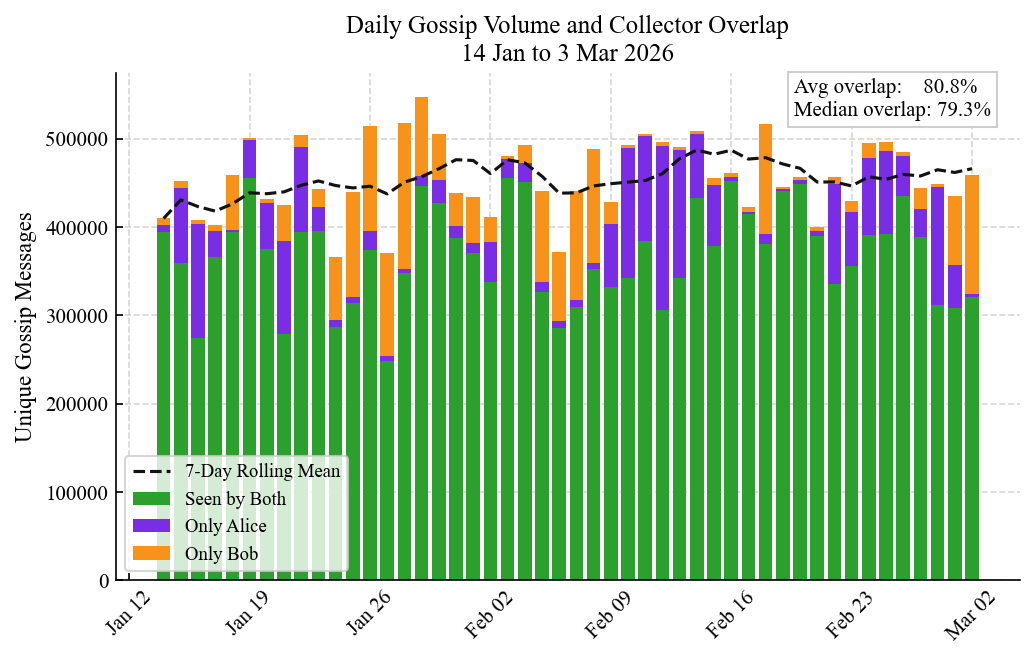

In [17]:
fig, ax = plt.subplots()

dates = df_network_volume_overlap["collection_date"]
w = 0.8 

ax.bar(dates, df_network_volume_overlap["both_nodes"], width=w, color=COLOR_BOTH,  label="Seen by Both")
ax.bar(dates, df_network_volume_overlap["only_alice"],
        width=w, color=COLOR_ALICE, label="Only Alice",
        bottom=df_network_volume_overlap["both_nodes"])
ax.bar(dates, df_network_volume_overlap["only_bob"],
        width=w, color=COLOR_BOB,   label="Only Bob",
        bottom=df_network_volume_overlap["both_nodes"] + df_network_volume_overlap["only_alice"])  

ax.plot(dates, df_network_volume_overlap["rolling_mean"],
        color=COLORS["text"], linewidth=1.5, linestyle="--",
        label="7-Day Rolling Mean", zorder=5)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=1))
ax.tick_params(axis="x", rotation=45)
ax.set_ylabel("Unique Gossip Messages") 
ax.set_title(f"Daily Gossip Volume and Collector Overlap\n{beautiful_timerange}") 
ax.legend() 

# Summary stats annotation
overlap_pct    = df_network_volume_overlap["both_nodes"] / df_network_volume_overlap["total"] 
avg_overlap    = overlap_pct.mean()   * 100 
median_overlap = overlap_pct.median() * 100
ax.text(
    0.75, 0.99,
    f"Avg overlap:    {avg_overlap:.1f}%\n"
    f"Median overlap: {median_overlap:.1f}%",
    transform=ax.transAxes, va="top",
    bbox=dict(facecolor=COLORS["background"], edgecolor=COLORS["border"],
            boxstyle="square", alpha=0.95),
)

print("Average Overlap", avg_overlap)
print("Median Overlap", median_overlap)
fig.tight_layout()
save_plot_for_latex(fig, file_name="network-gossip-volume-and-overlap", file_path="../resources/results-final")

In [43]:
sql_bw_sizes = f"""--sql
    SELECT 256 AS type, AVG(OCTET_LENGTH(c.raw_gossip)) AS avg_bytes
    FROM channels c
    JOIN gossip_inventory i ON i.gossip_id = c.gossip_id
    WHERE i.first_seen_at >= '{START_DATETIME_STR}'::timestamptz
      AND i.first_seen_at <  '{END_DATETIME_STR}'::timestamptz

    UNION ALL

    SELECT 257, AVG(OCTET_LENGTH(na.raw_gossip))
    FROM node_announcements na
    JOIN gossip_inventory i ON i.gossip_id = na.gossip_id
    WHERE i.first_seen_at >= '{START_DATETIME_STR}'::timestamptz
      AND i.first_seen_at <  '{END_DATETIME_STR}'::timestamptz

    UNION ALL

    SELECT 258, AVG(OCTET_LENGTH(cu.raw_gossip))
    FROM channel_updates cu
    JOIN gossip_inventory i ON i.gossip_id = cu.gossip_id
    WHERE i.first_seen_at >= '{START_DATETIME_STR}'::timestamptz
      AND i.first_seen_at <  '{END_DATETIME_STR}'::timestamptz

    ORDER BY type;
"""

df_bw_sizes = run_query(sql_bw_sizes)

msg_counts = {256: 13045, 257: 6575334, 258: 14493905}
type_names = {256: "Channel Announcement", 257: "Node Announcement", 258: "Channel Update"}

# Per-node factor based on observed overlap from df_1a.
# Each collector receives (both + only_self) messages; average across Alice and Bob.
total_both       = df_network_volume_overlap["both_nodes"].sum()
total_only_alice = df_network_volume_overlap["only_alice"].sum()
total_only_bob   = df_network_volume_overlap["only_bob"].sum()
total_unique     = df_network_volume_overlap["total"].sum()

alice_msgs = total_both + total_only_alice
bob_msgs   = total_both + total_only_bob
per_node_factor = ((alice_msgs + bob_msgs) / 2) / total_unique

print(f"Per-node factor: {per_node_factor:.4f}  "
      f"(Alice: {alice_msgs/total_unique:.4f}, Bob: {bob_msgs/total_unique:.4f})")

size_map = dict(zip(df_bw_sizes["type"].astype(int), df_bw_sizes["avg_bytes"]))

rows = []
for t in [256, 257, 258]:
    avg_b          = size_map[t]
    n              = msg_counts[t]
    total_bytes    = avg_b * n
    per_node_bytes = total_bytes * per_node_factor
    rows.append({
        "Type":             t,
        "Name":             type_names[t],
        "Avg Size (bytes)": round(avg_b, 1),
        "Unique Messages":  n,
        "Total (MB)":       round(total_bytes / 1e6, 2),
        "Per Node (MB)":    round(per_node_bytes / 1e6, 2),
    })

df_bw = pd.DataFrame(rows)
grand_total_MB = df_bw["Per Node (MB)"].sum()

print(df_bw.to_string(index=False))
print(f"Estimated total bandwidth per collector node: {grand_total_MB:.1f} MB  ({grand_total_MB / 1024:.3f} GB)") # REVIEW


Per-node factor: 0.9036  (Alice: 0.9107, Bob: 0.8965)
 Type                 Name  Avg Size (bytes)  Unique Messages  Total (MB)  Per Node (MB)
  256 Channel Announcement             435.0            13045        5.67           5.13
  257    Node Announcement             502.3          6575334     3302.95        2984.53
  258       Channel Update             143.0         14493905     2073.23        1873.37
Estimated total bandwidth per collector node: 4863.0 MB  (4.749 GB)


### Propergation Lag by msg_type
Timestamp of signing the message vs actual recieving it.
Only look at the `gossip_observation` table. For every gossip message calculate the difference between the `seen_at` and the `sender_timestamp`. 
Group the differences by msg_type.

In [29]:
sql_propergation_lag = f"""--sql
  SELECT
      inv.type,
      EXTRACT(EPOCH FROM (o.seen_at - o.sender_timestamp)) AS lag_seconds
  FROM gossip_observations o
  JOIN gossip_inventory inv ON o.internal_id = inv.internal_id
  WHERE inv.first_seen_at >= '{START_DATETIME_STR}'::timestamptz
    AND inv.first_seen_at <  '{END_DATETIME_STR}'::timestamptz
    AND o.sender_timestamp IS NOT NULL;
  """

df_propergation_lag = run_query(sql_propergation_lag)

Plot saved to: ../resources/results-final/propagation-lag.pdf


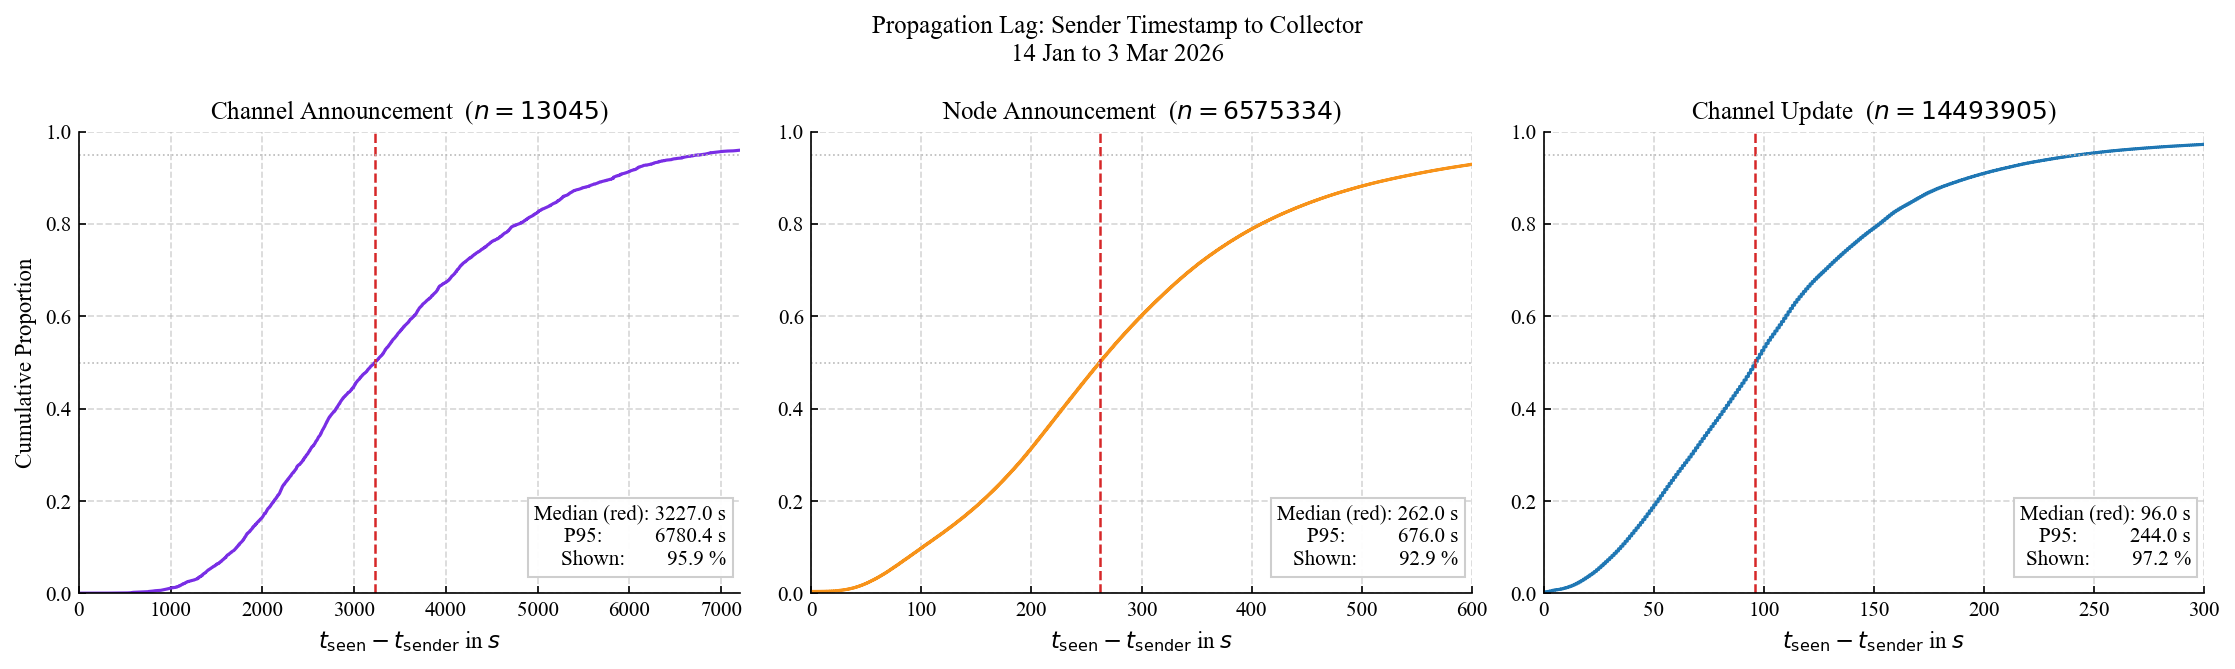

In [30]:
#channel announcement timestamp to set for the timestamp of the 6th block ?

x_cutoffs = {
    256: 7200,
    257: 600,
    258: 300,
}

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4.5))

for i, msg_type in enumerate([256, 257, 258]):
    ax     = axes[i]
    subset = df_propergation_lag.loc[df_propergation_lag["type"] == msg_type, "lag_seconds"]
    cutoff = x_cutoffs[msg_type]

    # Empirical CDF
    sorted_vals = np.sort(subset)
    cdf         = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
    in_window   = sorted_vals <= cutoff
    ax.plot(
        sorted_vals[in_window], cdf[in_window],
        color=type_colors[msg_type], linewidth=1.5,
    )

    median_val = subset.median()
    p95_val    = subset.quantile(0.95)
    pct_shown  = (subset <= cutoff).mean() * 100

    # Vertical line at median; horizontal guides at 0.50 and 0.95
    ax.axvline(median_val, color=COLORS["red"],     linewidth=1.2, linestyle="--")
    ax.axhline(0.50,       color=COLORS["passive"], linewidth=0.8, linestyle=":")
    ax.axhline(0.95,       color=COLORS["passive"], linewidth=0.8, linestyle=":")

    ax.set_xlim(0, cutoff)
    ax.set_ylim(0, 1)
    ax.set_title(f"{type_names[msg_type]}  ($n={len(subset)}$)")
    ax.set_xlabel(r"$t_{\mathrm{seen}} - t_{\mathrm{sender}}$ in $s$")
    if i == 0:
        ax.set_ylabel("Cumulative Proportion")

    stats_text = (
        f"Median (red): {median_val:.1f} s\n"
        f"P95:          {p95_val:.1f} s\n"
        f"Shown:        {pct_shown:.1f} %"
    )
    # Bottom-right: the CDF curve is sparse there since it already plateaus
    ax.text(
        0.98, 0.05, stats_text,
        transform=ax.transAxes, va="bottom", ha="right",
        bbox=dict(
            facecolor=COLORS["background"],
            edgecolor=COLORS["border"],
            boxstyle="square",
            alpha=0.95,
        ),
    )

fig.suptitle(
    f"Propagation Lag: Sender Timestamp to Collector\n"
    f"{beautiful_timerange}"
)

fig.tight_layout()
save_plot_for_latex(fig, "propagation-lag", file_path="../resources/results-final")

Plot saved to: ../resources/results-final/propagation-lag-large.pdf


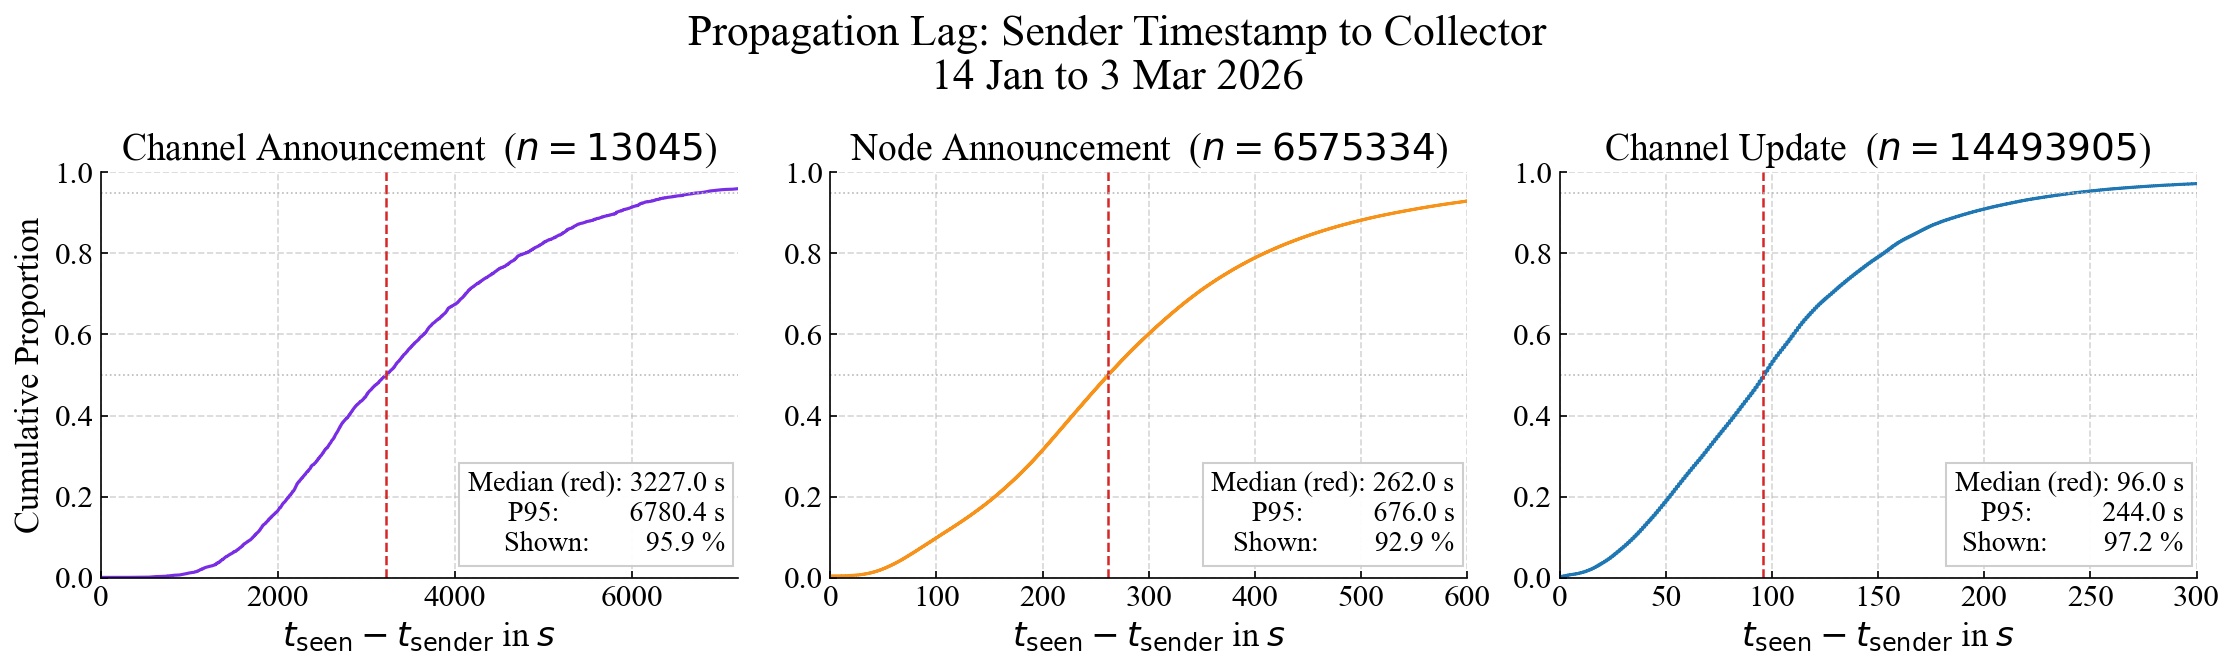

In [43]:
FONT_SCALE = 1.5 

x_cutoffs = {
    256: 7200,
    257: 600,
    258: 300,
}

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4.5))

for i, msg_type in enumerate([256, 257, 258]):
    ax     = axes[i]
    subset = df_propergation_lag.loc[df_propergation_lag["type"] == msg_type, "lag_seconds"]
    cutoff = x_cutoffs[msg_type]

    sorted_vals = np.sort(subset)
    cdf         = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
    in_window   = sorted_vals <= cutoff
    ax.plot(
        sorted_vals[in_window], cdf[in_window],
        color=type_colors[msg_type], linewidth=1.5,
    )

    median_val = subset.median()
    p95_val    = subset.quantile(0.95)
    pct_shown  = (subset <= cutoff).mean() * 100

    ax.axvline(median_val, color=COLORS["red"],     linewidth=1.2, linestyle="--")
    ax.axhline(0.50,       color=COLORS["passive"], linewidth=0.8, linestyle=":")
    ax.axhline(0.95,       color=COLORS["passive"], linewidth=0.8, linestyle=":")

    ax.set_xlim(0, cutoff)
    ax.set_ylim(0, 1)
    ax.set_title(f"{type_names[msg_type]}  ($n={len(subset)}$)", fontsize=12 * FONT_SCALE)
    ax.set_xlabel(r"$t_{\mathrm{seen}} - t_{\mathrm{sender}}$ in $s$", fontsize=11 * FONT_SCALE)
    ax.tick_params(axis="both", labelsize=10 * FONT_SCALE)
    if i == 0:
        ax.set_ylabel("Cumulative Proportion", fontsize=11 * FONT_SCALE)

    stats_text = (
        f"Median (red): {median_val:.1f} s\n"
        f"P95:          {p95_val:.1f} s\n"
        f"Shown:        {pct_shown:.1f} %"
    )
    ax.text(
        0.98, 0.05, stats_text,
        transform=ax.transAxes, va="bottom", ha="right",
        fontsize=9 * FONT_SCALE,
        bbox=dict(
            facecolor=COLORS["background"],
            edgecolor=COLORS["border"],
            boxstyle="square",
            alpha=0.95,
        ),
    )

fig.suptitle(
    f"Propagation Lag: Sender Timestamp to Collector\n"
    f"{beautiful_timerange}",
    fontsize=14 * FONT_SCALE,
)

fig.tight_layout()
save_plot_for_latex(fig, "propagation-lag-large", file_path="../resources/results-final")

### Lag between 2 nodes
A new gossip messsage is propagated through the Lightning Network by nodes forwarding them to their peers. Currently, two Core-Lightning nodes (*Alice* and *Bob*) collect all gossip and timestamp each message with the collection time (`seen_at`) and store it in the `gossip_observations` table.

We look at all gossip messages that have been collected by *both* collector nodes and analyze the lag between both nodes have recieved it.

In [31]:
sql_inter_connection_lag = f"""--sql
  SELECT
      inv.type,
      ABS(EXTRACT(EPOCH FROM (obs_a.seen_at - obs_b.seen_at))) AS lag_seconds
  FROM gossip_observations obs_a
  JOIN gossip_observations obs_b
      ON  obs_a.internal_id       = obs_b.internal_id
      AND obs_a.collector_node_id = '{ALICE_ID}'
      AND obs_b.collector_node_id = '{BOB_ID}'
  JOIN gossip_inventory inv
      ON obs_a.internal_id = inv.internal_id
  WHERE inv.first_seen_at >= '{START_DATETIME_STR}'::timestamptz
    AND inv.first_seen_at <  '{END_DATETIME_STR}'::timestamptz;
  """

df_inter_connection_lag = run_query(sql_inter_connection_lag)
df_inter_connection_lag.head()

,type,lag_seconds
0,257,26.0
1,257,0.0
2,257,47.0
3,257,89.0
4,257,32.0


In [32]:
# Remove channel_announcements (256) that have lag_seconds > 600 (those messages are retrived because of restarts of the collector node and can be ignored)
df_inter_connection_lag = df_inter_connection_lag[~((df_inter_connection_lag['type'] == 256) & (df_inter_connection_lag['lag_seconds'] > 600))]

Plot saved to: ../resources/results-final/inter-collection-lag.pdf


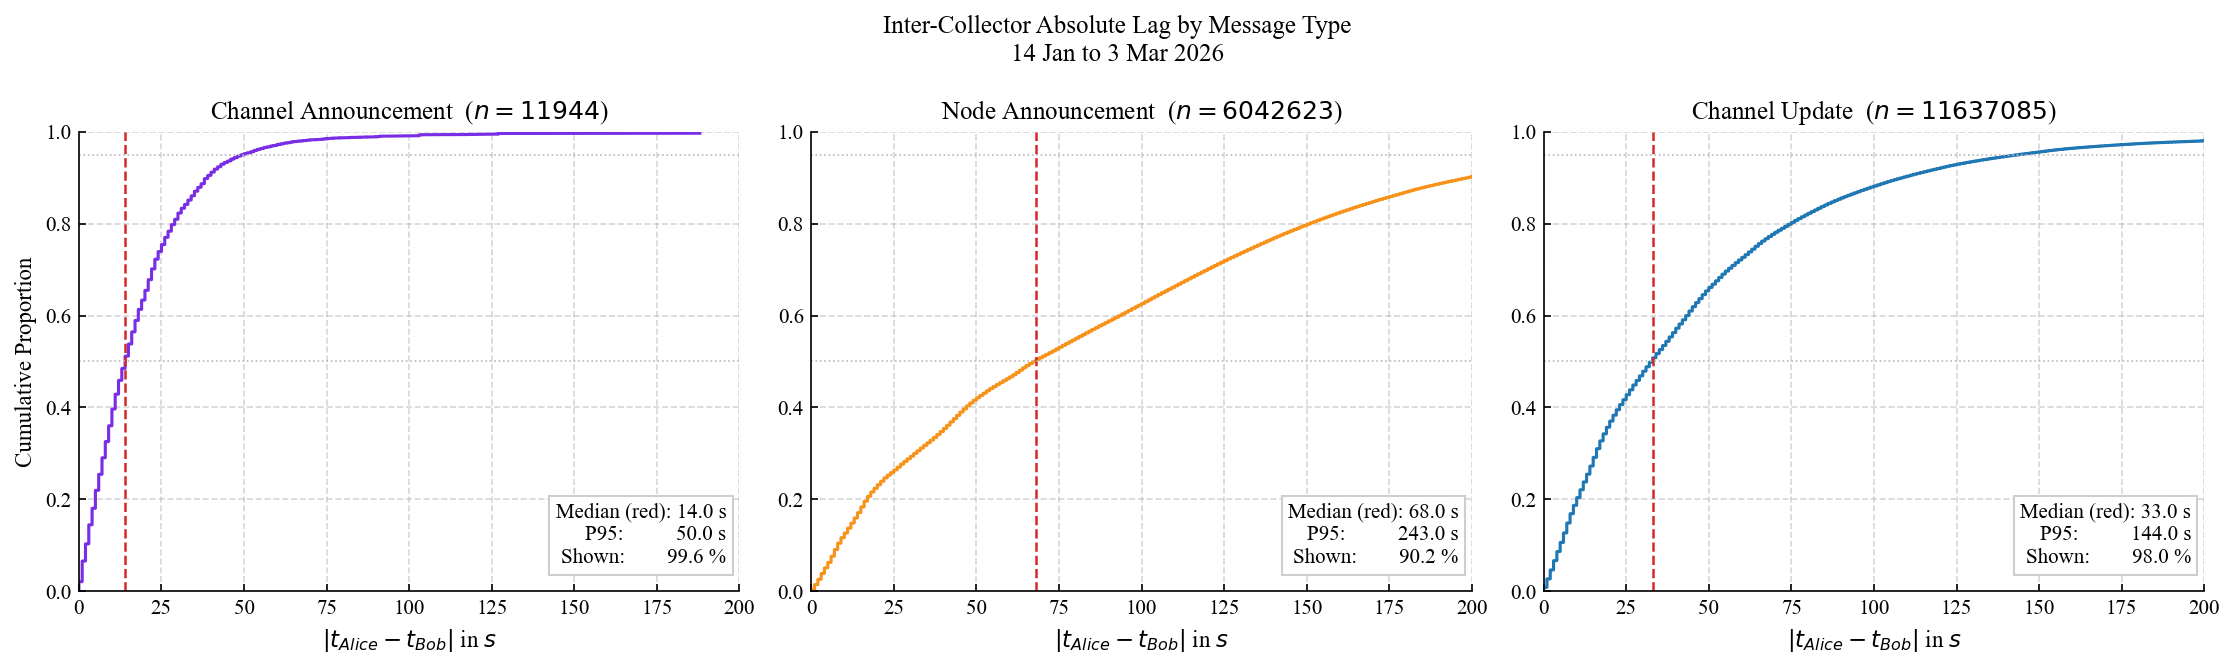

In [39]:
x_cutoffs = {
    256: 200,
    257: 200,
    258: 200,
}

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4.5))

for i, msg_type in enumerate([256, 257, 258]):
    ax     = axes[i]
    subset = df_inter_connection_lag.loc[df_inter_connection_lag["type"] == msg_type, "lag_seconds"]
    cutoff = x_cutoffs[msg_type]

    # Empirical CDF
    sorted_vals = np.sort(subset)
    cdf         = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
    in_window   = sorted_vals <= cutoff
    ax.plot(
        sorted_vals[in_window], cdf[in_window],
        color=type_colors[msg_type], linewidth=1.5,
    )

    median_val = subset.median()
    p95_val    = subset.quantile(0.95)
    pct_shown  = (subset <= cutoff).mean() * 100

    ax.axvline(median_val, color=COLORS["red"],     linewidth=1.2, linestyle="--")
    ax.axhline(0.50,       color=COLORS["passive"], linewidth=0.8, linestyle=":")
    ax.axhline(0.95,       color=COLORS["passive"], linewidth=0.8, linestyle=":")

    ax.set_xlim(0, cutoff)
    ax.set_ylim(0, 1)
    ax.set_title(f"{type_names[msg_type]}  ($n={len(subset)}$)")
    ax.set_xlabel(r"$| t_{Alice} - t_{Bob}|$ in $s$")
    if i == 0:
        ax.set_ylabel("Cumulative Proportion")

    stats_text = (
        f"Median (red): {median_val:.1f} s\n"
        f"P95:          {p95_val:.1f} s\n"
        f"Shown:        {pct_shown:.1f} %"
    )
    ax.text(
        0.98, 0.05, stats_text,
        transform=ax.transAxes, va="bottom", ha="right",
        bbox=dict(
            facecolor=COLORS["background"],
            edgecolor=COLORS["border"],
            boxstyle="square",
            alpha=0.95,
        ),
    )

fig.suptitle(
    f"Inter-Collector Absolute Lag by Message Type\n"
    f"{beautiful_timerange}"
)

fig.tight_layout()
save_plot_for_latex(fig, "inter-collection-lag", file_path="../resources/results-final")

Plot saved to: ../resources/results/1c_inter_collector_lag_large-2026-05-10_13:16:55.pdf


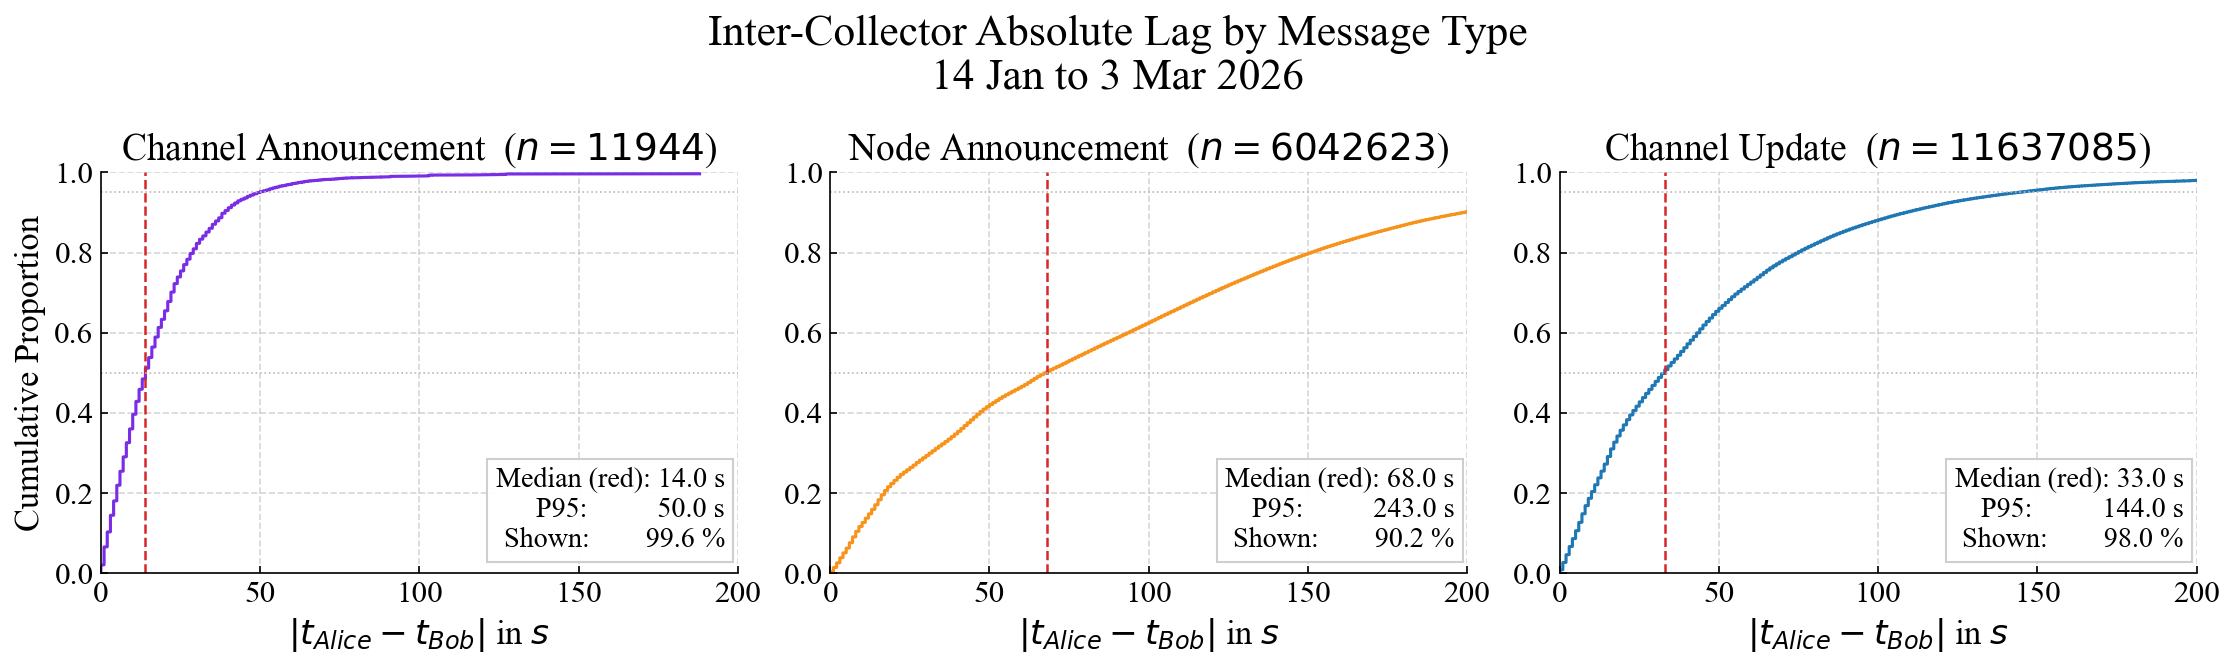

In [ ]:
FONT_SCALE = 1.5 

x_cutoffs = {
    256: 200,
    257: 200,
    258: 200,
}

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4.5))

for i, msg_type in enumerate([256, 257, 258]):
    ax     = axes[i]
    subset = df_inter_connection_lag.loc[df_inter_connection_lag["type"] == msg_type, "lag_seconds"]
    cutoff = x_cutoffs[msg_type]

    sorted_vals = np.sort(subset)
    cdf         = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
    in_window   = sorted_vals <= cutoff
    ax.plot(
        sorted_vals[in_window], cdf[in_window],
        color=type_colors[msg_type], linewidth=1.5,
    )

    median_val = subset.median()
    p95_val    = subset.quantile(0.95)
    pct_shown  = (subset <= cutoff).mean() * 100

    ax.axvline(median_val, color=COLORS["red"],     linewidth=1.2, linestyle="--")
    ax.axhline(0.50,       color=COLORS["passive"], linewidth=0.8, linestyle=":")
    ax.axhline(0.95,       color=COLORS["passive"], linewidth=0.8, linestyle=":")

    ax.set_xlim(0, cutoff)
    ax.set_ylim(0, 1)
    ax.set_title(f"{type_names[msg_type]}  ($n={len(subset)}$)", fontsize=12 * FONT_SCALE)
    ax.set_xlabel(r"$| t_{Alice} - t_{Bob}|$ in $s$",            fontsize=11 * FONT_SCALE)
    ax.tick_params(axis="both", labelsize=10 * FONT_SCALE)
    if i == 0:
        ax.set_ylabel("Cumulative Proportion", fontsize=11 * FONT_SCALE)

    stats_text = (
        f"Median (red): {median_val:.1f} s\n"
        f"P95:          {p95_val:.1f} s\n"
        f"Shown:        {pct_shown:.1f} %"
    )
    ax.text(
        0.98, 0.05, stats_text,
        transform=ax.transAxes, va="bottom", ha="right",
        fontsize=9 * FONT_SCALE,
        bbox=dict(
            facecolor=COLORS["background"],
            edgecolor=COLORS["border"],
            boxstyle="square",
            alpha=0.95,
        ),
    )

fig.suptitle(
    f"Inter-Collector Absolute Lag by Message Type\n"
    f"{beautiful_timerange}",
    fontsize=14 * FONT_SCALE,
)

fig.tight_layout()
save_plot_for_latex(fig, "inter-collector-lag-large", file_path="../resources/results-final")

## Peer Session Analysis

### Peer Session Distriubtion

The `peer_session` table has columns `connected_at`, `disconnected_at` of type timestamptz and `collector_node_id` which is type string.
We have the two collector nodes: Alice and Bob.

In on figure we want to show the distribution of the peer session lengths (disconnected_at - connected_at).

Only looking at the timeframe: 


In [34]:
sql_peer_sessions = f"""--sql
SELECT                                                                                                                                                                                                      
    collector_node_id,                                                                                                                                                                                    
    EXTRACT(EPOCH FROM (disconnected_at - connected_at)) AS duration_seconds                                                                                                                                                                                                        
FROM peer_sessions
WHERE disconnected_at IS NOT NULL
AND connected_at >= '{START_DATETIME_STR}'::timestamptz
AND connected_at <  '{END_DATETIME_STR}'::timestamptz
"""

df_peer_sessions = run_query(sql_peer_sessions)
# Only work with sessions longer than 1 hour because nodes sometimes restarted
df_peer_sessions = df_peer_sessions[df_peer_sessions["duration_seconds"] > 3600].copy() 

df_alice_sess = df_peer_sessions.loc[df_peer_sessions["collector_node_id"] == ALICE_ID, "duration_seconds"]
df_bob_sess   = df_peer_sessions.loc[df_peer_sessions["collector_node_id"] == BOB_ID,   "duration_seconds"]

print(f"Alice sessions: {len(df_alice_sess):,}")
print(f"Bob sessions:   {len(df_bob_sess):,}")
df_peer_sessions.head()

Alice sessions: 423
Bob sessions:   439


,collector_node_id,duration_seconds
0,023bcaddce800a81dc9ab077c4bbf160cf17d6d3673457...,56935.346265
1,023bcaddce800a81dc9ab077c4bbf160cf17d6d3673457...,10082.042343
2,023bcaddce800a81dc9ab077c4bbf160cf17d6d3673457...,28951.573464
4,023bcaddce800a81dc9ab077c4bbf160cf17d6d3673457...,48586.151074
5,023bcaddce800a81dc9ab077c4bbf160cf17d6d3673457...,209190.133182


Plot saved to: ../resources/results/peer_session_distribution-2026-05-09_18:33:11.pdf


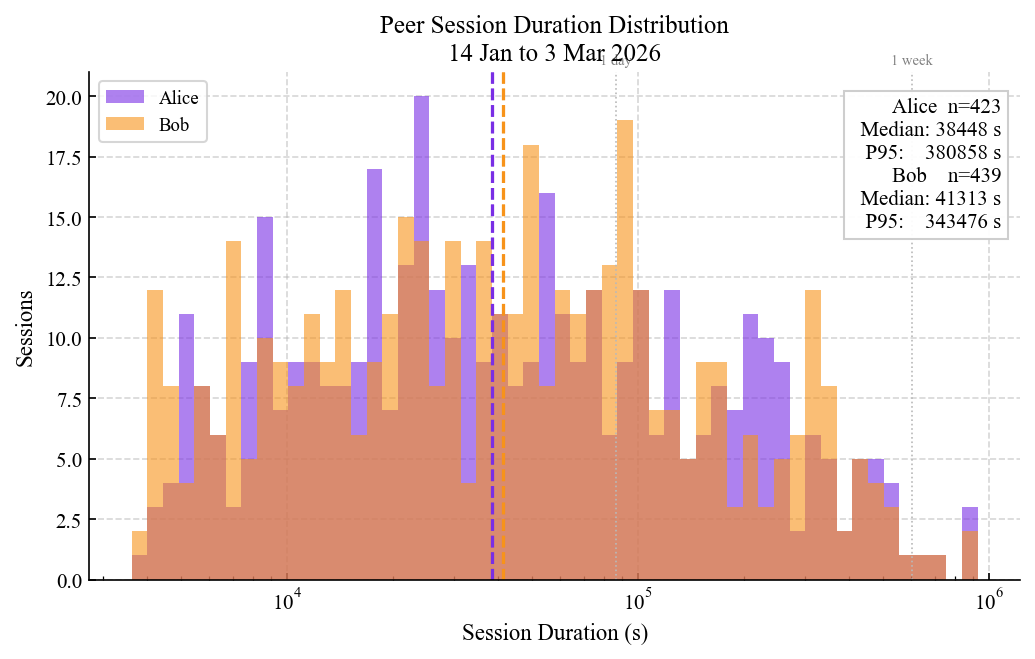

In [35]:
fig, ax = plt.subplots() 
                                                                                         
lo = max(pd.concat([df_alice_sess, df_bob_sess]).min(), 1)
hi = pd.concat([df_alice_sess, df_bob_sess]).max()                                                                                                                                                          
bins = np.logspace(np.log10(lo), np.log10(hi), 55)
                                                                                                                                                                                                            
ax.hist(df_alice_sess, bins=bins, color=COLOR_ALICE, alpha=0.6, label="Alice", edgecolor="none")
ax.hist(df_bob_sess,   bins=bins, color=COLOR_BOB,   alpha=0.6, label="Bob",   edgecolor="none")

for secs, label in [(3600, "1 h"), (86400, "1 day"), (86400* 7, "1 week")]:
    if lo <= secs <= hi:
        ax.axvline(secs, color=COLORS["passive"], linewidth=0.8, linestyle=":", zorder=1)
        ax.text(secs, 1.01, label, transform=ax.get_xaxis_transform(), ha="center", va="bottom", fontsize=7, color=COLORS["gray"])

        ax.axvline(df_alice_sess.median(), color=COLOR_ALICE, linewidth=1.5, linestyle="--")
        ax.axvline(df_bob_sess.median(),   color=COLOR_BOB,   linewidth=1.5, linestyle="--")

ax.set_xscale("log")
ax.set_xlabel("Session Duration (s)")
ax.set_ylabel("Sessions")
ax.set_title(f"Peer Session Duration Distribution\n{beautiful_timerange}")
ax.legend(loc="upper left")

stats_text = (
    f"Alice  n={len(df_alice_sess):,}\n"
    f"  Median: {df_alice_sess.median():.0f} s\n"
    f"  P95:    {df_alice_sess.quantile(0.95):.0f} s\n"
    f"Bob    n={len(df_bob_sess):,}\n"
    f"  Median: {df_bob_sess.median():.0f} s\n"
    f"  P95:    {df_bob_sess.quantile(0.95):.0f} s"
)
ax.text(
    0.98, 0.95, stats_text,
    transform=ax.transAxes, va="top", ha="right",
    bbox=dict(facecolor=COLORS["background"], edgecolor=COLORS["border"],
            boxstyle="square", alpha=0.95),
)

fig.tight_layout()
save_plot_for_latex(fig, "peer_session_distribution")

### Corelation do peers with bigger node_size have longer peer_sessions?

For all connected peers calculate the node_size (once with the active lifespan (for normalization) and once with the given start_time and end_time).
Then scatter plot the results with the session duration. We want to see if it there is a correlation.

In [36]:
sql_peer_node_size = f"""--sql
WITH peer_node_ids AS (
    SELECT DISTINCT peer_node_id AS node_id
    FROM peer_sessions
    WHERE disconnected_at IS NOT NULL
      AND connected_at >= '{START_DATETIME_STR}'::timestamptz
      AND connected_at <  '{END_DATETIME_STR}'::timestamptz
),
channel_sides_window AS (
    SELECT source_node_id AS node_id, capacity_sat, funding_timestamp,
           COALESCE(closing_timestamp, '{END_DATETIME_STR}'::timestamptz) AS effective_closing
    FROM channels
    WHERE source_node_id IN (SELECT node_id FROM peer_node_ids)
      AND funding_timestamp IS NOT NULL
      AND funding_timestamp < '{END_DATETIME_STR}'::timestamptz
      AND (closing_timestamp IS NULL OR closing_timestamp > '{START_DATETIME_STR}'::timestamptz)
    UNION ALL
    SELECT target_node_id, capacity_sat, funding_timestamp,
           COALESCE(closing_timestamp, '{END_DATETIME_STR}'::timestamptz) AS effective_closing
    FROM channels
    WHERE target_node_id IN (SELECT node_id FROM peer_node_ids)
      AND funding_timestamp IS NOT NULL
      AND funding_timestamp < '{END_DATETIME_STR}'::timestamptz
      AND (closing_timestamp IS NULL OR closing_timestamp > '{START_DATETIME_STR}'::timestamptz)
),
node_size_window AS (
    SELECT node_id,
           SUM(
               capacity_sat * EXTRACT(EPOCH FROM (
                   LEAST(effective_closing, '{END_DATETIME_STR}'::timestamptz)
                 - GREATEST(funding_timestamp, '{START_DATETIME_STR}'::timestamptz)
               ))
           ) / EXTRACT(EPOCH FROM (
               '{END_DATETIME_STR}'::timestamptz - '{START_DATETIME_STR}'::timestamptz
           )) AS node_size_sat
    FROM channel_sides_window
    GROUP BY node_id
),
channel_sides_all AS (
    SELECT source_node_id AS node_id, capacity_sat, funding_timestamp,
           COALESCE(closing_timestamp, NOW()) AS effective_closing
    FROM channels
    WHERE source_node_id IN (SELECT node_id FROM peer_node_ids)
      AND funding_timestamp IS NOT NULL
    UNION ALL
    SELECT target_node_id, capacity_sat, funding_timestamp,
           COALESCE(closing_timestamp, NOW()) AS effective_closing
    FROM channels
    WHERE target_node_id IN (SELECT node_id FROM peer_node_ids)
      AND funding_timestamp IS NOT NULL
),
node_lifespan AS (
    SELECT node_id,
           MIN(funding_timestamp) AS ls_start,
           MAX(effective_closing) AS ls_end
    FROM channel_sides_all
    GROUP BY node_id
),
node_size_lifespan AS (
    SELECT ca.node_id,
           SUM(
               ca.capacity_sat * EXTRACT(EPOCH FROM (ca.effective_closing - ca.funding_timestamp))
           ) / NULLIF(EXTRACT(EPOCH FROM (nl.ls_end - nl.ls_start)), 0) AS node_size_sat
    FROM channel_sides_all ca
    JOIN node_lifespan nl ON ca.node_id = nl.node_id
    GROUP BY ca.node_id, nl.ls_end, nl.ls_start  -- FIX: Added nl columns to GROUP BY
),
session_stats AS (
    SELECT peer_node_id AS node_id,
           COUNT(*) AS session_count,
           PERCENTILE_CONT(0.5) WITHIN GROUP (
               ORDER BY EXTRACT(EPOCH FROM (disconnected_at - connected_at))
           ) AS median_duration_s
    FROM peer_sessions
    WHERE disconnected_at IS NOT NULL
      AND connected_at >= '{START_DATETIME_STR}'::timestamptz
      AND connected_at <  '{END_DATETIME_STR}'::timestamptz
    GROUP BY peer_node_id
)
SELECT
    ss.node_id,
    ss.session_count,
    ss.median_duration_s,
    nsw.node_size_sat AS node_size_window_sat,
    nsl.node_size_sat AS node_size_lifespan_sat
FROM session_stats ss
JOIN node_size_window  nsw ON ss.node_id = nsw.node_id
JOIN node_size_lifespan nsl ON ss.node_id = nsl.node_id
ORDER BY nsw.node_size_sat DESC;
"""

df_peer_node_size = run_query(sql_peer_node_size)

# Filter for active/valid entries
df_peer_node_size = df_peer_node_size[
    (df_peer_node_size["node_size_window_sat"]   > 0) &
    (df_peer_node_size["node_size_lifespan_sat"] > 0) &
    (df_peer_node_size["median_duration_s"]      > 0)
].copy()

# Convert satoshis to BTC
df_peer_node_size["node_size_window_btc"]   = df_peer_node_size["node_size_window_sat"]   / 1e8
df_peer_node_size["node_size_lifespan_btc"] = df_peer_node_size["node_size_lifespan_sat"] / 1e8

print(f"Peers with node_size + sessions: {len(df_peer_node_size):,}")
df_peer_node_size.head()

Peers with node_size + sessions: 653


,node_id,session_count,median_duration_s,node_size_window_sat,node_size_lifespan_sat,node_size_window_btc,node_size_lifespan_btc
0,03864ef025fde8fb587d989186ce6a4a186895ee44a926...,2,104976.575736,3.025373e+10,1.485982e+10,302.537250,148.598221
1,034ea80f8b148c750463546bd999bf7321a0e6dfc60aaf...,1,527684.942423,2.924220e+10,8.169782e+09,292.421966,81.697821
2,027100442c3b79f606f80f322d98d499eefcb060599efc...,1,8849.298451,1.643236e+10,9.284944e+09,164.323610,92.849442
3,0322d0e43b3d92d30ed187f4e101a9a9605c3ee5fc9721...,1,274564.905870,1.482551e+10,5.710378e+09,148.255135,57.103781
4,026165850492521f4ac8abd9bd8088123446d126f648ca...,1,160455.967351,1.273703e+10,2.450310e+09,127.370344,24.503100


Plot saved to: ../resources/results-final/corelation-node-size-and-session-duration.pdf


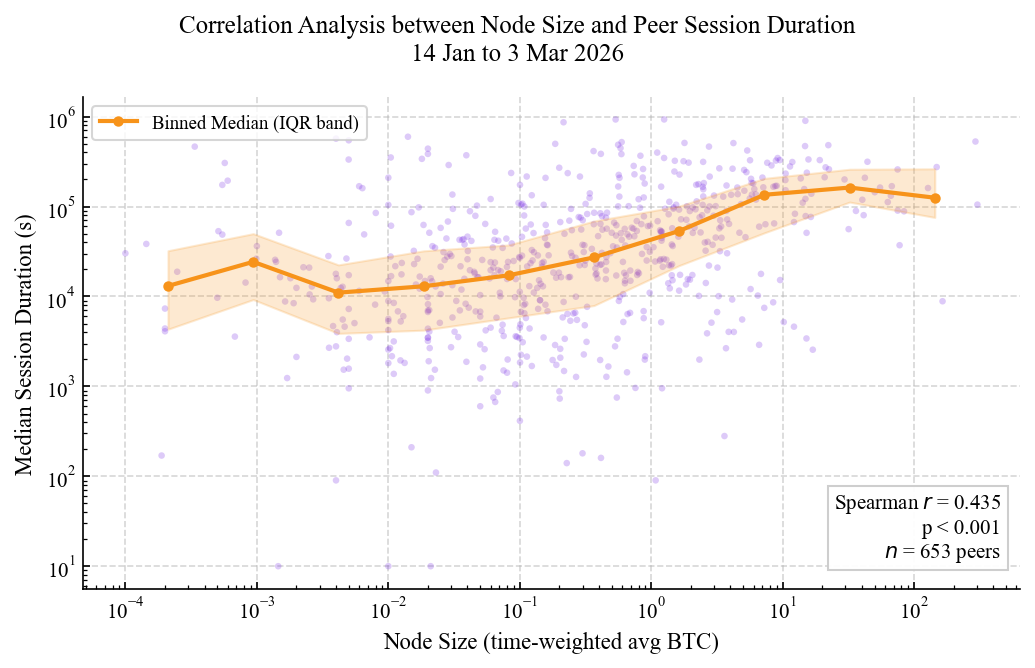

In [37]:
fig, ax = plt.subplots()

col = "node_size_window_btc"
xlabel = "Node Size (time-weighted avg BTC)"

x_log = np.log10(df_peer_node_size[col].clip(lower=1e-8))
y_raw = df_peer_node_size["median_duration_s"]

r, p = stats.spearmanr(x_log, y_raw)

cx, med, lo, hi = _binned_median(x_log, y_raw, n_bins=10)

ax.scatter(
    df_peer_node_size[col], y_raw,
    color=COLORS["lightning"], alpha=0.25, s=10, edgecolors="none", zorder=2,
)

ax.fill_between(10**cx, lo, hi, color=COLORS["bitcoin"], alpha=0.2, zorder=3)

ax.plot(
    10**cx, med,
    color=COLORS["bitcoin"], linewidth=2, marker="o", markersize=4,
    label="Binned Median (IQR band)", zorder=4,
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(xlabel)
ax.set_ylabel("Median Session Duration (s)")
ax.legend(loc="upper left")

p_str = "p < 0.001" if p < 0.001 else f"p = {p:.3f}" # type: ignore
ax.text(
    0.98, 0.05,
    f"Spearman $r$ = {r:.3f}\n{p_str}\n$n$ = {len(df_peer_node_size):,} peers",
    transform=ax.transAxes, va="bottom", ha="right",
    bbox=dict(facecolor=COLORS["background"], edgecolor=COLORS["border"], boxstyle="square", alpha=0.95),
)

fig.suptitle(f"Correlation Analysis between Node Size and Peer Session Duration\n{beautiful_timerange}")
fig.tight_layout()

save_plot_for_latex(fig, "corelation-node-size-and-session-duration", file_path="../resources/results-final")

## Historic Gossip Analysis

In [24]:
SNAPSHOTS_DIR = Path(".") / "snapshots"

CENTRALITY_PALETTE = [
    COLORS["lightning"], COLORS["bitcoin"], COLORS["green"],
    COLORS["purple"],    COLORS["red"],     COLORS["orange"], COLORS["cyan"],
]


def _load_all_centrality() -> pd.DataFrame:
    frames = []
    for path in sorted(SNAPSHOTS_DIR.glob("*_centrality.csv")):
        df = pd.read_csv(path)
        df["date"] = pd.to_datetime(path.stem.replace("_centrality", ""))
        frames.append(df)
    if not frames:
        raise FileNotFoundError(f"No *_centrality.csv files found in {SNAPSHOTS_DIR}")
    return pd.concat(frames, ignore_index=True)


def _load_all_stats() -> pd.DataFrame:
    rows = []
    for path in sorted(SNAPSHOTS_DIR.glob("*_stats.json")):
        with open(path) as f:
            rows.append(json.load(f))
    df = pd.DataFrame(rows)
    df["date"] = pd.to_datetime(df["date"])
    return df[df["nodes_total"] > 0].reset_index(drop=True)


def _load_all_capacities() -> pd.DataFrame:
    """
    Loads all *_capacities.json snapshots and returns a tidy DataFrame with
    one row per (date, scid) plus a summary column for total/median capacity.
    """
    rows = []
    for path in sorted(SNAPSHOTS_DIR.glob("*_capacities.json")):
        with open(path) as f:
            data: dict = json.load(f)
        if not data:
            continue
        date = pd.to_datetime(path.stem.replace("_capacities", ""))
        capacities = np.array(list(data.values()), dtype=np.int64)
        rows.append({
            "date":           date,
            "channel_count":  len(capacities),
            "total_sat":      int(capacities.sum()),
            "median_sat":     float(np.median(capacities)),
            "mean_sat":       float(capacities.mean()),
            "p25_sat":        float(np.percentile(capacities, 25)),
            "p75_sat":        float(np.percentile(capacities, 75)),
            "p95_sat":        float(np.percentile(capacities, 95)),
        })
    df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
    df["total_btc"]  = df["total_sat"]  / 1e8
    df["median_btc"] = df["median_sat"] / 1e8
    return df


def _gini(scores: np.ndarray) -> float:
    s = np.sort(scores)
    n = len(s)
    if n == 0 or s.sum() == 0:
        return 0.0
    idx = np.arange(1, n + 1)
    return float((2 * idx - n - 1).dot(s) / (n * s.sum()))


def _lorenz_xy(scores: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    s = np.sort(scores)
    cum = np.cumsum(s)
    x = np.insert(np.arange(1, len(s) + 1) / len(s), 0, 0.0)
    y = np.insert(cum / cum[-1] if cum[-1] > 0 else cum, 0, 0.0)
    return x, y


def _top_pct_share(scores: np.ndarray, pct: float) -> float:
    if scores.sum() == 0:
        return 0.0
    k = max(1, int(np.ceil(len(scores) * pct / 100)))
    return float(np.sort(scores)[-k:].sum() / scores.sum())


def _build_time_series(df: pd.DataFrame) -> pd.DataFrame:
    records = []
    for date, grp in df.groupby("date"):
        sc = grp["betweenness_centrality"].values
        records.append({
            "date":      date,
            "gini":      _gini(sc), # pyright: ignore[reportArgumentType]
            "top1_pct":  _top_pct_share(sc, 1), # pyright: ignore[reportArgumentType]
            "top5_pct":  _top_pct_share(sc, 5), # pyright: ignore[reportArgumentType]
            "top10_pct": _top_pct_share(sc, 10), # pyright: ignore[reportArgumentType]
        })
    return pd.DataFrame(records).sort_values("date").reset_index(drop=True)


df_centrality    = _load_all_centrality()
df_stats         = _load_all_stats()
df_capacities    = _load_all_capacities()
ts_centrality    = _build_time_series(df_centrality)

print(
    f"{df_centrality['date'].nunique()} snapshots  |  {len(df_centrality):,} rows  "
    f"({df_centrality['date'].min().strftime('%Y-%m')} → {df_centrality['date'].max().strftime('%Y-%m')})"
)
print(f"{len(df_stats)} non-empty stats snapshots")
print(f"{len(df_capacities)} capacity snapshots  |  "
      f"total BTC range: {df_capacities['total_btc'].min():.0f} – {df_capacities['total_btc'].max():.0f}")

88 snapshots  |  989,754 rows  (2019-01 → 2026-04)
99 non-empty stats snapshots
78 capacity snapshots  |  total BTC range: 484 – 2885


### Network Evolution

#### Distribution of Gossip Messages

In [20]:
sql_gossip_distribution = """
SELECT
    DATE_TRUNC('month', ts) AS month,
    type,
    COUNT(*) AS message_count
FROM (
    SELECT 256 AS type, funding_timestamp AS ts
    FROM channels
    WHERE funding_timestamp IS NOT NULL

    UNION ALL

    SELECT 257, valid_from
    FROM node_announcements
    WHERE valid_from IS NOT NULL

    UNION ALL

    SELECT 258, valid_from
    FROM channel_updates
    WHERE valid_from IS NOT NULL
) sub
GROUP BY month, type
ORDER BY month, type
"""

df_gossip_dist = run_query(sql_gossip_distribution)

df_gossip_dist["month"] = pd.to_datetime(df_gossip_dist["month"])

print(df_gossip_dist.head(5))

                      month  type  message_count
0 2018-01-01 00:00:00+00:00   256            262
1 2018-02-01 00:00:00+00:00   256            567
2 2018-02-01 00:00:00+00:00   257             14
3 2018-03-01 00:00:00+00:00   256            686
4 2018-03-01 00:00:00+00:00   257             20


Plot saved to: ../resources/results-final/gossip-distribution-by-type.pdf


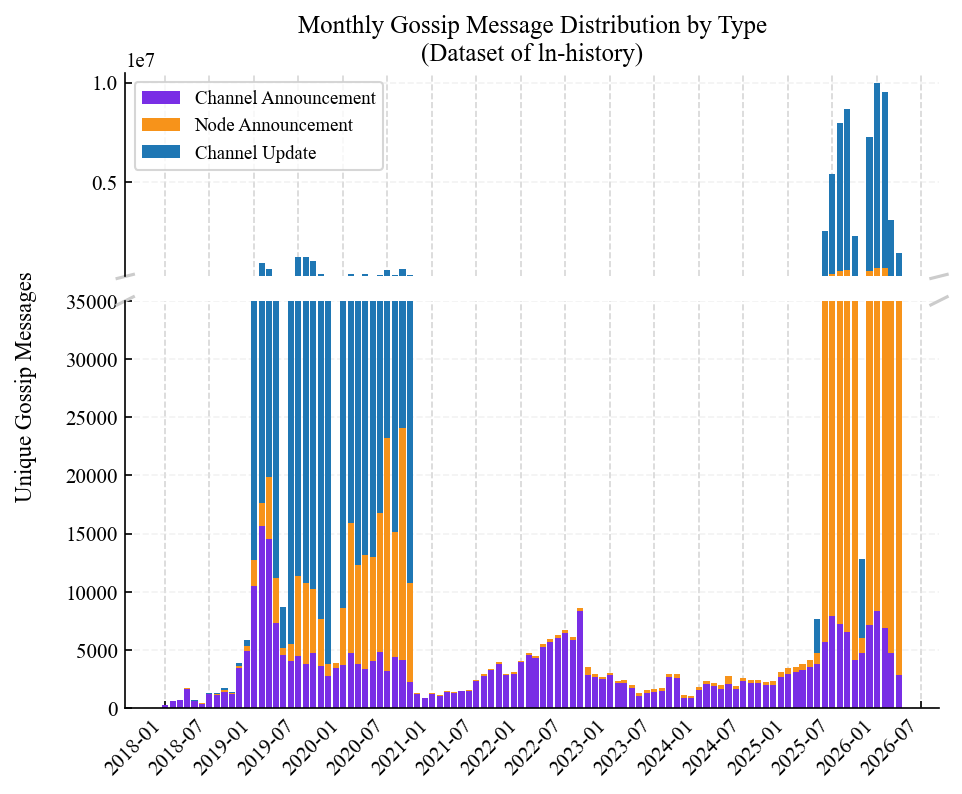

In [21]:
pivot = (
    df_gossip_dist
    .pivot(index="month", columns="type", values="message_count")
    .fillna(0)
)

Y_BREAK_BOTTOM = 35_000   # The highest "normal" value to show on the bottom chart
Y_BREAK_TOP = 250_000     # The lowest "outlier" value to start the top chart

fig, (ax1, ax2) = plt.subplots(
    2, 1, 
    sharex=True, 
    figsize=(7, 5.5), 
    gridspec_kw={'height_ratios': [1, 2]}
)
fig.subplots_adjust(hspace=0.08)

for ax in [ax1, ax2]:
    bottom = np.zeros(len(pivot))
    for msg_type in [256, 257, 258]:
        if msg_type not in pivot.columns:
            continue
        values = pivot[msg_type].values
        ax.bar(
            pivot.index, values,
            bottom=bottom,
            width=25,
            color=type_colors[msg_type],
            # Only add labels to the top axis so the legend doesn't duplicate
            label=type_names[msg_type] if ax == ax1 else "",
            edgecolor="none",
        )
        bottom += values # type: ignore

# Calculate the absolute max height of any stacked bar for the top limit
max_total = pivot.sum(axis=1).max()
ax1.set_ylim(Y_BREAK_TOP, max_total * 1.05)  # Top chart shows outliers
ax2.set_ylim(0, Y_BREAK_BOTTOM)              # Bottom chart shows standard months

ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.tick_params(bottom=False, labelbottom=False)  # Remove ticks from bottom of top plot

d = 0.01  # Size of the diagonal line
kwargs = dict(transform=ax1.transAxes, color=COLORS["border"], clip_on=False, linewidth=1.5)
ax1.plot((-d, +d), (-d, +d), **kwargs)        # Top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha="right")

fig.text(0.02, 0.5, "Unique Gossip Messages", va='center', rotation='vertical', fontsize=11)

ax1.set_title("Monthly Gossip Message Distribution by Type\n(Dataset of ln-history)")
ax1.legend(loc="upper left")

ax1.grid(True, axis='y', linestyle="--", alpha=0.5, color=COLORS["grid"])
ax2.grid(True, axis='y', linestyle="--", alpha=0.5, color=COLORS["grid"])

save_plot_for_latex(fig, "gossip-distribution-by-type", file_path="../resources/results-final")

### Network Growth

Node count (left axis) and channel count (right axis) across all monthly snapshots.

Plot saved to: ../resources/results-final/network-growth.pdf


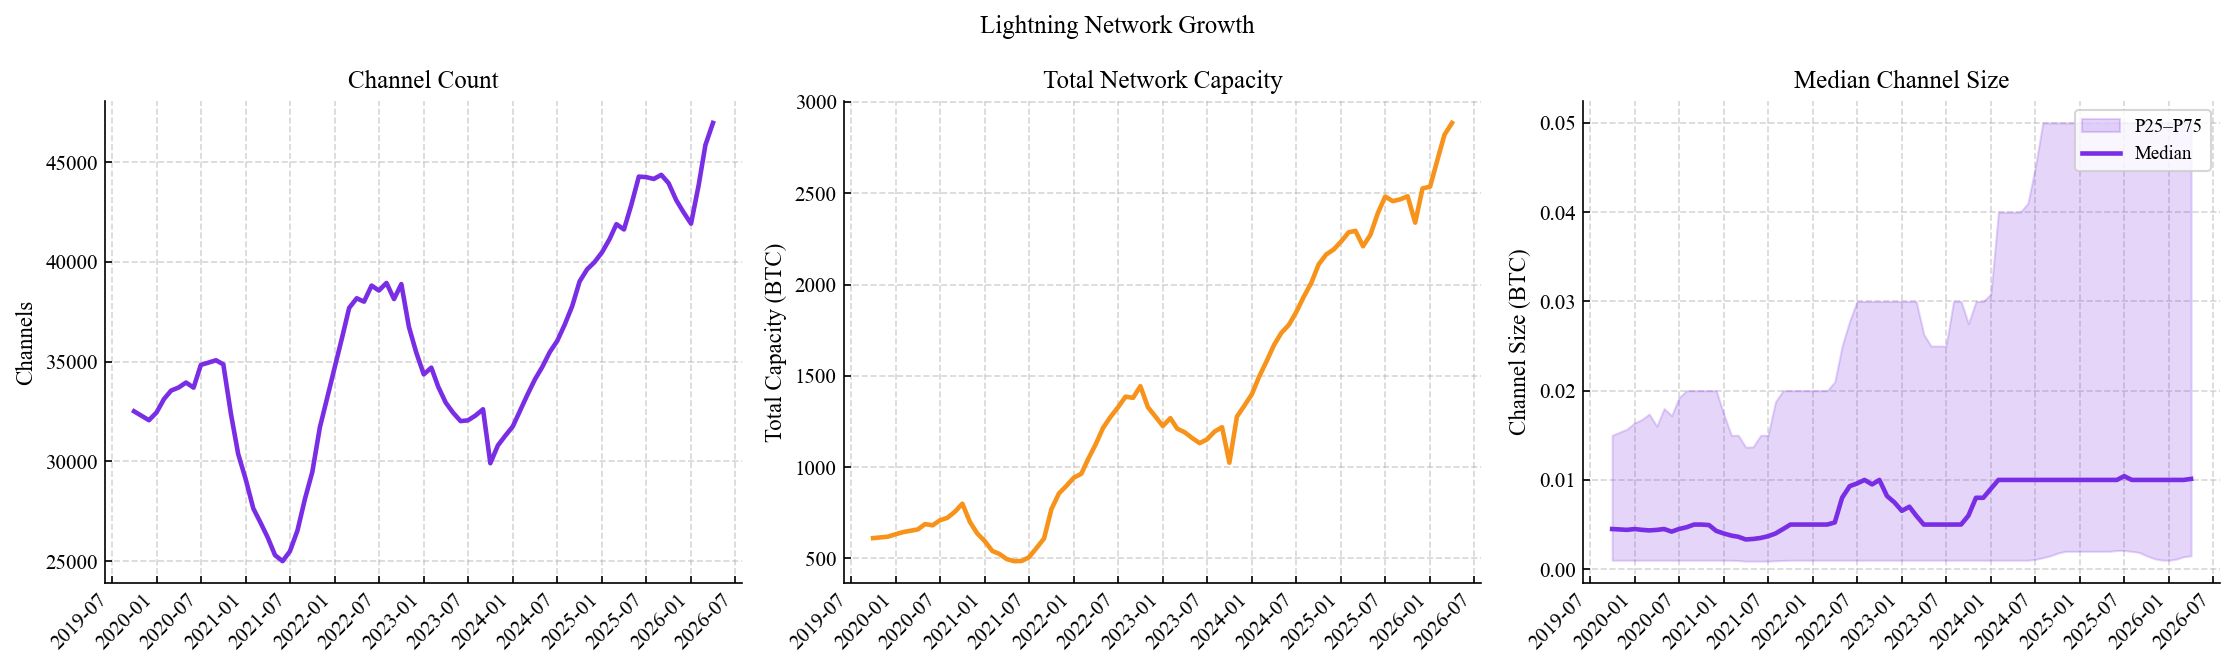

In [25]:
p25_btc = df_capacities["p25_sat"] / 1e8
p75_btc = df_capacities["p75_sat"] / 1e8

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4.5))

# --- Panel 1: Channel count ---
ax = axes[0]
ax.plot(df_capacities["date"], df_capacities["channel_count"],
        color=COLORS["lightning"], lw=2.2)
ax.set_ylabel("Channels")
ax.set_title("Channel Count")

# --- Panel 2: Total network capacity ---
ax = axes[1]
ax.plot(df_capacities["date"], df_capacities["total_btc"],
        color=COLORS["bitcoin"], lw=2.2)
ax.set_ylabel("Total Capacity (BTC)")
ax.set_title("Total Network Capacity")

# --- Panel 3: Median channel size with IQR band ---
ax = axes[2]
ax.fill_between(df_capacities["date"], p25_btc, p75_btc,
                color=COLORS["lightning"], alpha=0.2, label="P25–P75")
ax.plot(df_capacities["date"], df_capacities["median_btc"],
        color=COLORS["lightning"], lw=2.2, label="Median")
ax.set_ylabel("Channel Size (BTC)")
ax.set_title("Median Channel Size")
ax.legend(loc="upper right")

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

fig.suptitle("Lightning Network Growth")
fig.tight_layout()
save_plot_for_latex(fig, "network-growth", file_path="../resources/results-final")

### Channels

Plot saved to: ../resources/results-final/median-channel-capacity.pdf


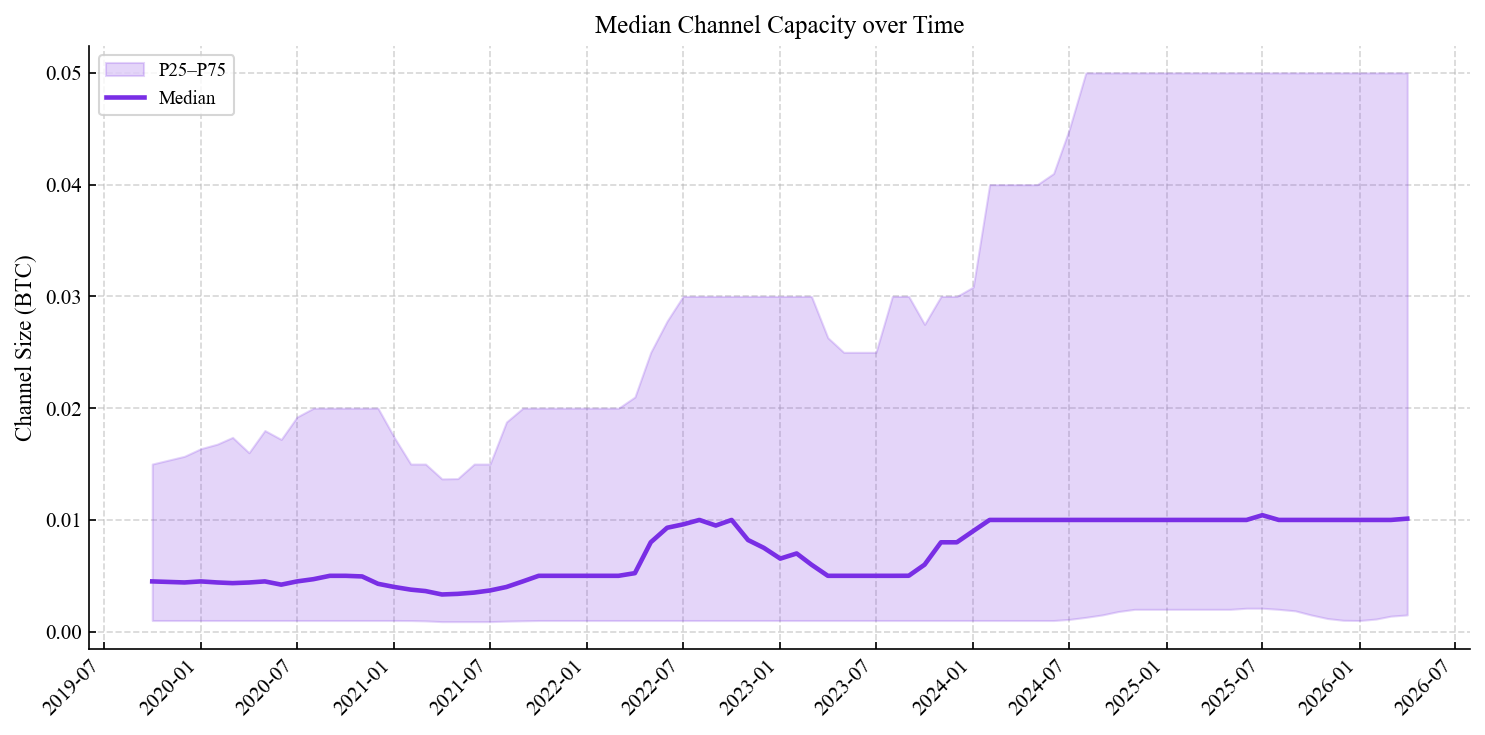

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))

p25_btc = df_capacities["p25_sat"] / 1e8
p75_btc = df_capacities["p75_sat"] / 1e8

ax.fill_between(df_capacities["date"], p25_btc, p75_btc,
                color=COLORS["lightning"], alpha=0.2, label="P25–P75")
ax.plot(df_capacities["date"], df_capacities["median_btc"],
        color=COLORS["lightning"], lw=2.2, label="Median")

ax.set_ylabel("Channel Size (BTC)")
ax.set_title("Median Channel Capacity over Time")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
ax.legend()

fig.tight_layout()
save_plot_for_latex(fig, "median-channel-capacity", file_path="../resources/results-final")

### Distribution of Channel Lifetime
In the channels table we have `funding_timestamp` and `closing_timestamp`. We for now only focus on closed channels. 
We want to have a bar plot that shows in bins (different time-lengths) how many channels had a lifetime like that.


In [18]:
sql_channel_lifetime = """
SELECT
    EXTRACT(EPOCH FROM (closing_timestamp - funding_timestamp)) / 86400.0 AS lifetime_days
FROM channels
WHERE funding_timestamp IS NOT NULL
  AND closing_timestamp IS NOT NULL
  AND closing_timestamp > funding_timestamp
"""

df_channel_lifetime = run_query(sql_channel_lifetime)

print(f"Closed channels: {len(df_channel_lifetime):,}")
print(f"  Median: {df_channel_lifetime['lifetime_days'].median():.1f} d")
print(f"  P25:    {df_channel_lifetime['lifetime_days'].quantile(0.25):.1f} d")
print(f"  P75:    {df_channel_lifetime['lifetime_days'].quantile(0.75):.1f} d")
print(f"  P95:    {df_channel_lifetime['lifetime_days'].quantile(0.95):.1f} d")
df_channel_lifetime.head()

Closed channels: 283,226
  Median: 81.9 d
  P25:    16.7 d
  P75:    248.0 d
  P95:    904.1 d


,lifetime_days
0,0.257373
1,1.434549
2,2.423437
3,1.865532
4,13.801794


Plot saved to: ../resources/results-final/channel-lifetime-distribution.pdf


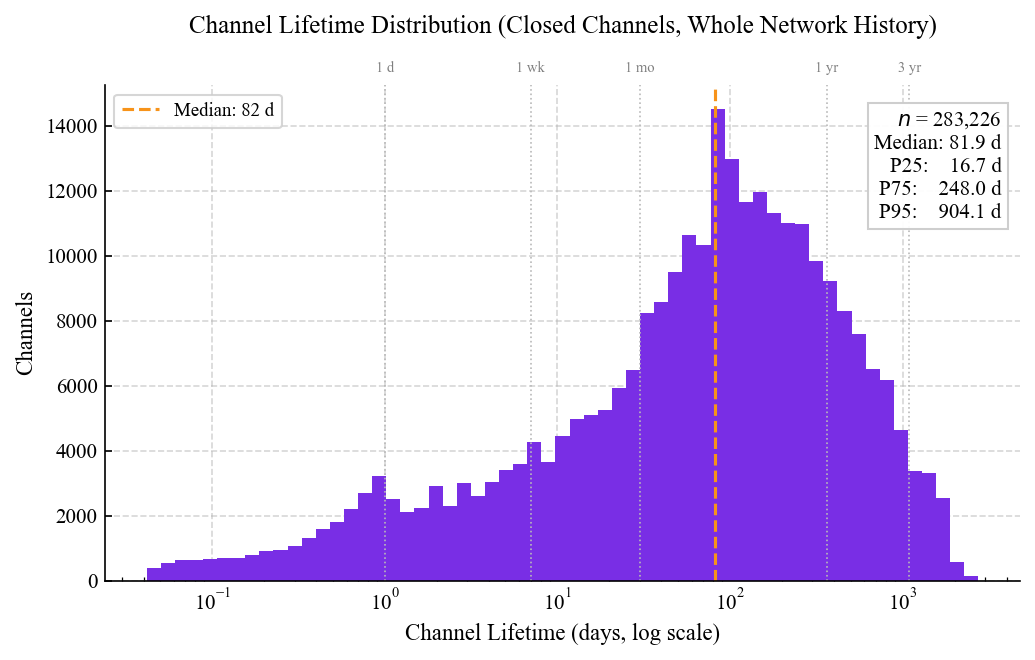

In [19]:
fig, ax = plt.subplots()

lifetime_days = df_channel_lifetime["lifetime_days"]

lo = max(lifetime_days.min(), 1 / 24)
hi = lifetime_days.max()
bins = np.logspace(np.log10(lo), np.log10(hi), 60)

ax.hist(lifetime_days, bins=bins, color=COLORS["lightning"], edgecolor="none")

milestones = [1, 7, 30, 365, 365 * 3]
labels = ["1 d", "1 wk", "1 mo", "1 yr", "3 yr"]
for secs, label in zip(milestones, labels):
    ax.axvline(secs, color=COLORS["passive"], linewidth=0.8, linestyle=":", zorder=1)
    ax.text(secs, 1.02, label,
            transform=ax.get_xaxis_transform(),
            ha="center", va="bottom", fontsize=7, color=COLORS["gray"])

median_val = lifetime_days.median()
ax.axvline(median_val, color=COLORS["bitcoin"], linewidth=1.5, linestyle="--",
           label=f"Median: {median_val:.0f} d")

ax.set_xscale("log")
ax.set_xlabel("Channel Lifetime (days, log scale)")
ax.set_ylabel("Channels")
ax.set_title("Channel Lifetime Distribution (Closed Channels, Whole Network History)", pad=25)
ax.legend()

stats_text = (
    f"$n$ = {len(lifetime_days):,}\n"
    f"Median: {lifetime_days.median():.1f} d\n"
    f"P25:    {lifetime_days.quantile(0.25):.1f} d\n"
    f"P75:    {lifetime_days.quantile(0.75):.1f} d\n"
    f"P95:    {lifetime_days.quantile(0.95):.1f} d"
)
ax.text(
    0.98, 0.95, stats_text,
    transform=ax.transAxes, va="top", ha="right",
    bbox=dict(facecolor=COLORS["background"], edgecolor=COLORS["border"],
              boxstyle="square", alpha=0.95),
)

fig.tight_layout()
save_plot_for_latex(fig, "channel-lifetime-distribution", file_path="../resources/results-final")

#### Channel Size to Channel Lifetime Correlation

In [22]:
sql_cap_lifetime = """--sql
SELECT
    capacity_sat,
    EXTRACT(EPOCH FROM (closing_timestamp - funding_timestamp)) / 86400.0 AS lifetime_days
FROM channels
WHERE funding_timestamp IS NOT NULL
  AND closing_timestamp IS NOT NULL
  AND closing_timestamp > funding_timestamp
  AND capacity_sat IS NOT NULL
  AND capacity_sat > 0
"""

df_cap_lifetime = run_query(sql_cap_lifetime)

# Convert capacity to BTC
df_cap_lifetime["capacity_btc"] = df_cap_lifetime["capacity_sat"] / 1e8

print(f"Closed channels with capacity: {len(df_cap_lifetime):,}")
df_cap_lifetime.head()

Closed channels with capacity: 283,227


,capacity_sat,lifetime_days,capacity_btc
0,200000000,0.257373,2.00
1,100000000,1.434549,1.00
2,100000000,2.423437,1.00
3,50000000,1.865532,0.50
4,75000000,13.801794,0.75


Plot saved to: ../resources/results-final/channel-capacity-lifetime-correlation.pdf


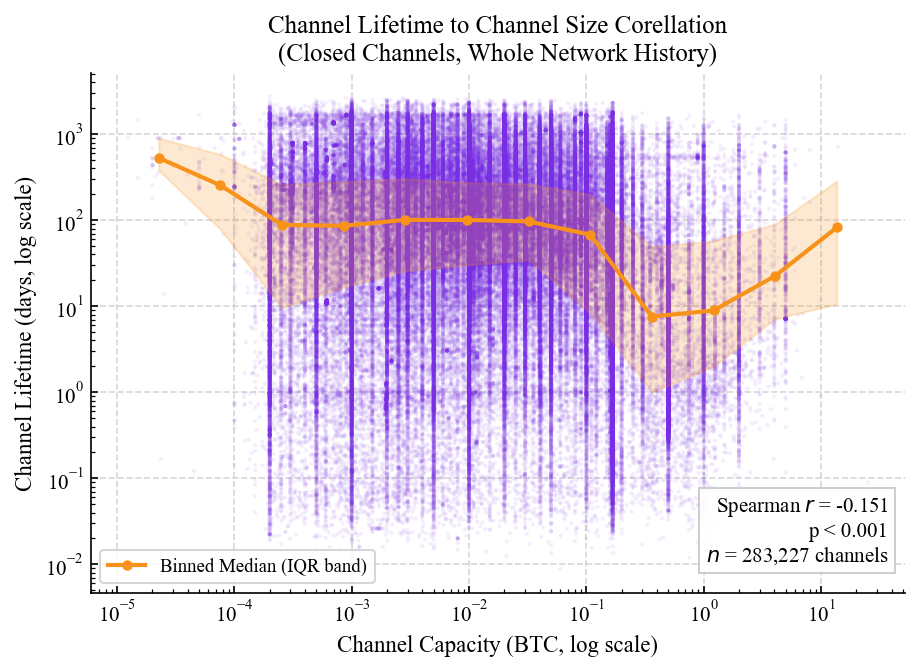

In [26]:
fig, ax = plt.subplots()

mask = df_cap_lifetime["capacity_btc"] > 0
x_log = np.log10(df_cap_lifetime.loc[mask, "capacity_btc"])
y_raw = df_cap_lifetime.loc[mask, "lifetime_days"]

r, p = stats.spearmanr(x_log, y_raw)
cx, med, lo, hi = _binned_median(x_log, y_raw, n_bins=12)

ax.scatter(
    df_cap_lifetime.loc[mask, "capacity_btc"], 
    y_raw,
    color=COLORS["lightning"], 
    alpha=0.08, 
    s=4, 
    edgecolors="none", 
    zorder=2
)

ax.fill_between(10**cx, lo, hi, color=COLORS["bitcoin"], alpha=0.2, zorder=3)
ax.plot(
    10**cx, med,
    color=COLORS["bitcoin"], 
    linewidth=2, 
    marker="o", 
    markersize=4,
    label="Binned Median (IQR band)", 
    zorder=4
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Channel Capacity (BTC, log scale)")
ax.set_ylabel("Channel Lifetime (days, log scale)")
ax.set_title("Channel Lifetime to Channel Size Corellation\n(Closed Channels, Whole Network History)")
ax.legend(loc="lower left")

p_str = "p < 0.001" if p < 0.001 else f"$p$ = {p:.3f}" # type: ignore
ax.text(
    0.98, 0.05,
    f"Spearman $r$ = {r:.3f}\n{p_str}\n$n$ = {mask.sum():,} channels",
    transform=ax.transAxes, 
    va="bottom", 
    ha="right",
    bbox=dict(
        facecolor=COLORS["background"], 
        edgecolor=COLORS["border"],
        boxstyle="square", 
        alpha=0.95
    )
)

save_plot_for_latex(fig, "channel-capacity-lifetime-correlation", file_path="../resources/results-final")

## Centrality Analysis

Historic betweenness centrality (BC) analysis across monthly Lightning Network snapshots stored in `snapshots/`. Each snapshot is the first-of-month graph; BC is approximated via Brandes k-sampling on the largest connected component.

### Betweenness Centrality Concentration

Betweenness centrality (BC) quantifies how often a node lies on the shortest path between other node pairs. A Gini coefficient close to 1 means routing power is concentrated in very few nodes.

Plot saved to: ../resources/results-final/centrality-gini.pdf


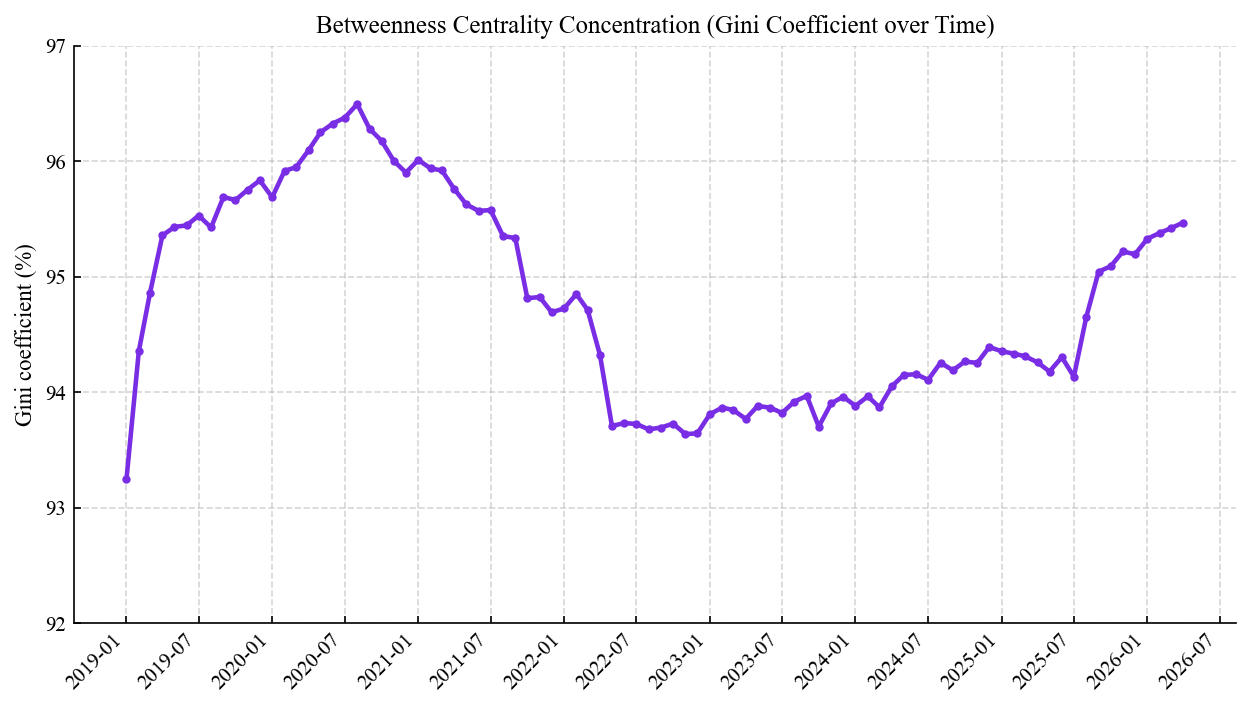

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(ts_centrality["date"], ts_centrality["gini"] * 100,
        color=COLORS["lightning"], lw=2.2, marker="o", ms=3)
ax.set_ylabel("Gini coefficient (%)")
ax.set_ylim(bottom=max(0, ts_centrality["gini"].min() * 100 - 5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
ax.set_ylim(92, 97)
ax.set_title("Betweenness Centrality Concentration (Gini Coefficient over Time)")

save_plot_for_latex(fig, "centrality-gini", file_path="../resources/results-final")

Plot saved to: ../resources/results-final/centrality-concentration-top-percentiles.pdf


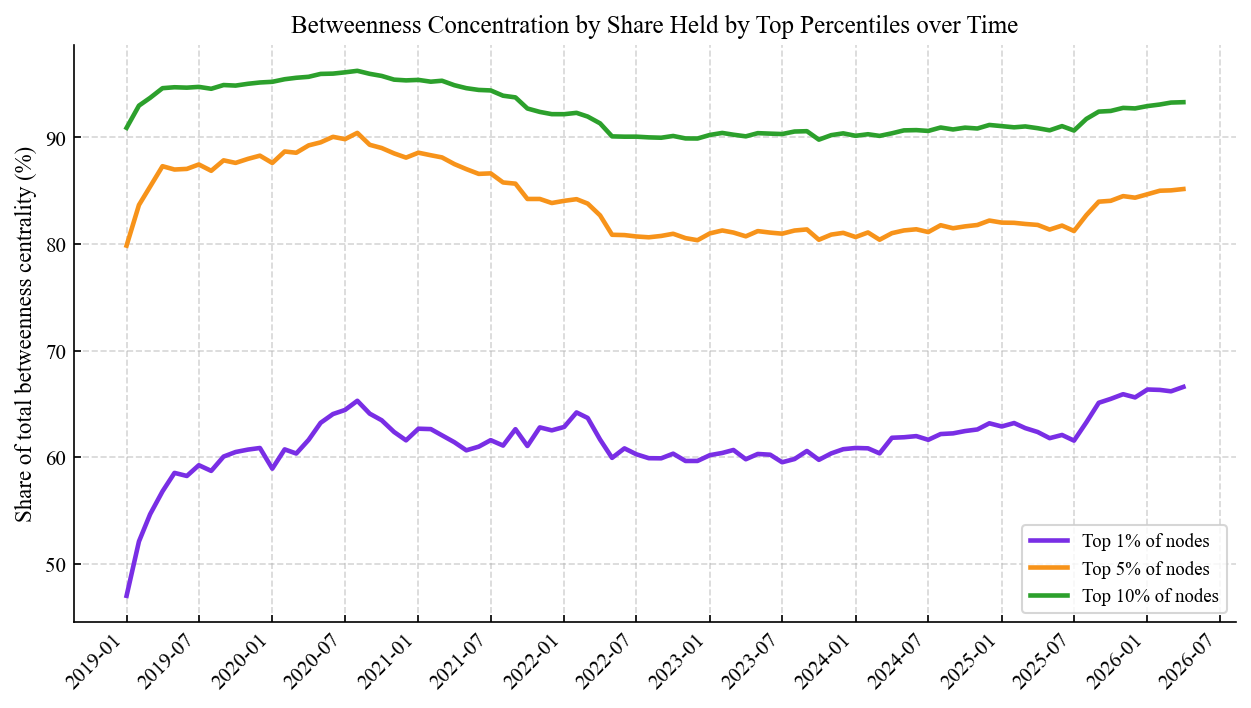

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
for col, label, color in [
    ("top1_pct",  "Top 1% of nodes",  COLORS["lightning"]),
    ("top5_pct",  "Top 5% of nodes",  COLORS["bitcoin"]),
    ("top10_pct", "Top 10% of nodes", COLORS["green"]),
]:
    ax.plot(ts_centrality["date"], ts_centrality[col] * 100,
            color=color, lw=2.2, label=label)

ax.set_ylabel("Share of total betweenness centrality (%)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
ax.legend()
ax.set_title("Betweenness Concentration by Share Held by Top Percentiles over Time")

save_plot_for_latex(fig, "centrality-concentration-top-percentiles", file_path="../resources/results-final")

### Lorenz Curve Evolution

Overlaid Lorenz curves for ~yearly snapshots. Darker blue = more recent. The diagonal dashed line represents perfect equality. Larger area between the curve and diagonal means higher inequality.

Plot saved to: ../resources/results-final/lorenz-curve.pdf


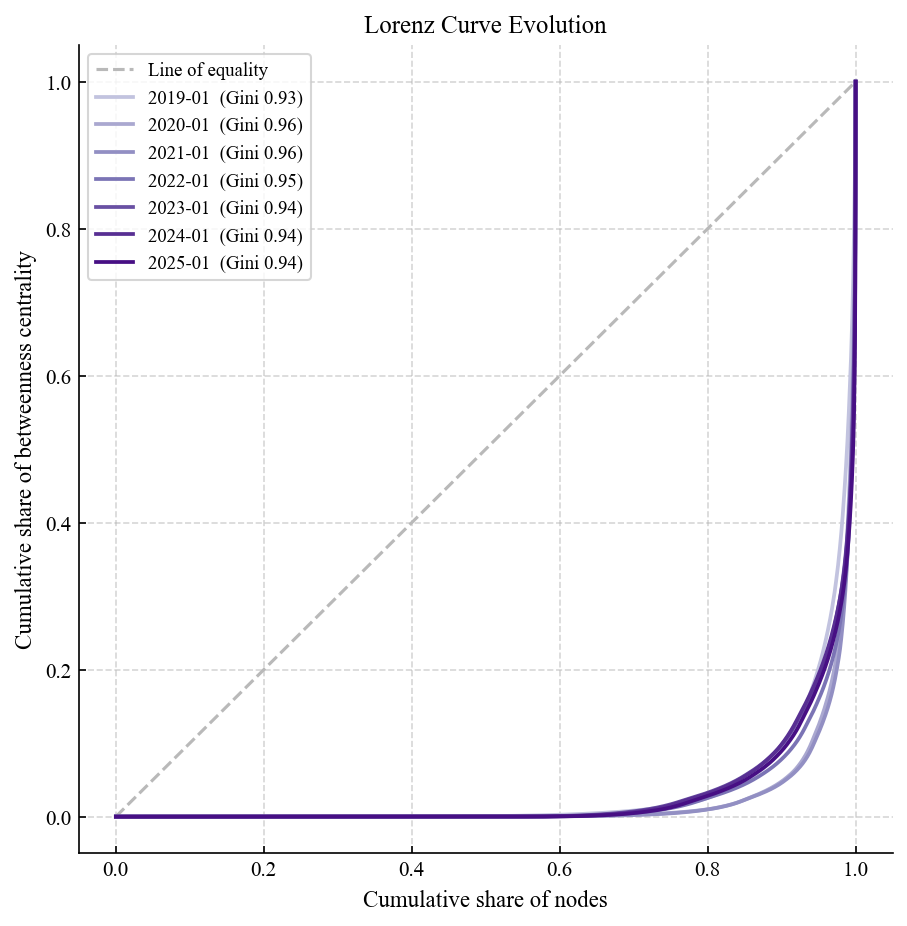

In [14]:
n_curves  = 7
all_dates = sorted(df_centrality["date"].unique())
step      = max(1, len(all_dates) // n_curves)
selected  = all_dates[::step][:n_curves]
cmap_vals = plt.cm.Purples(np.linspace(0.35, 0.95, len(selected))) # type: ignore

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], lw=1.5, color=COLORS["passive"], ls="--", label="Line of equality")

for color, snap_date in zip(cmap_vals, selected):
    sc = df_centrality[df_centrality["date"] == snap_date]["betweenness_centrality"].values
    x, y = _lorenz_xy(sc)
    g    = _gini(sc)
    ax.plot(x, y, lw=1.8, color=color,
            label=f"{snap_date.strftime('%Y-%m')}  (Gini {g:.2f})")

ax.set_xlabel("Cumulative share of nodes")
ax.set_ylabel("Cumulative share of betweenness centrality")
ax.set_title("Lorenz Curve Evolution")
ax.legend(loc="upper left", fontsize=9)

save_plot_for_latex(fig, "lorenz-curve", file_path="../resources/results-final")

### Top Nodes by Betweenness Centrality

The nodes that most persistently appear in the top-10 by BC score across all snapshots.

Plot saved to: ../resources/results-final/centrality-top-nodes-heatmap.pdf


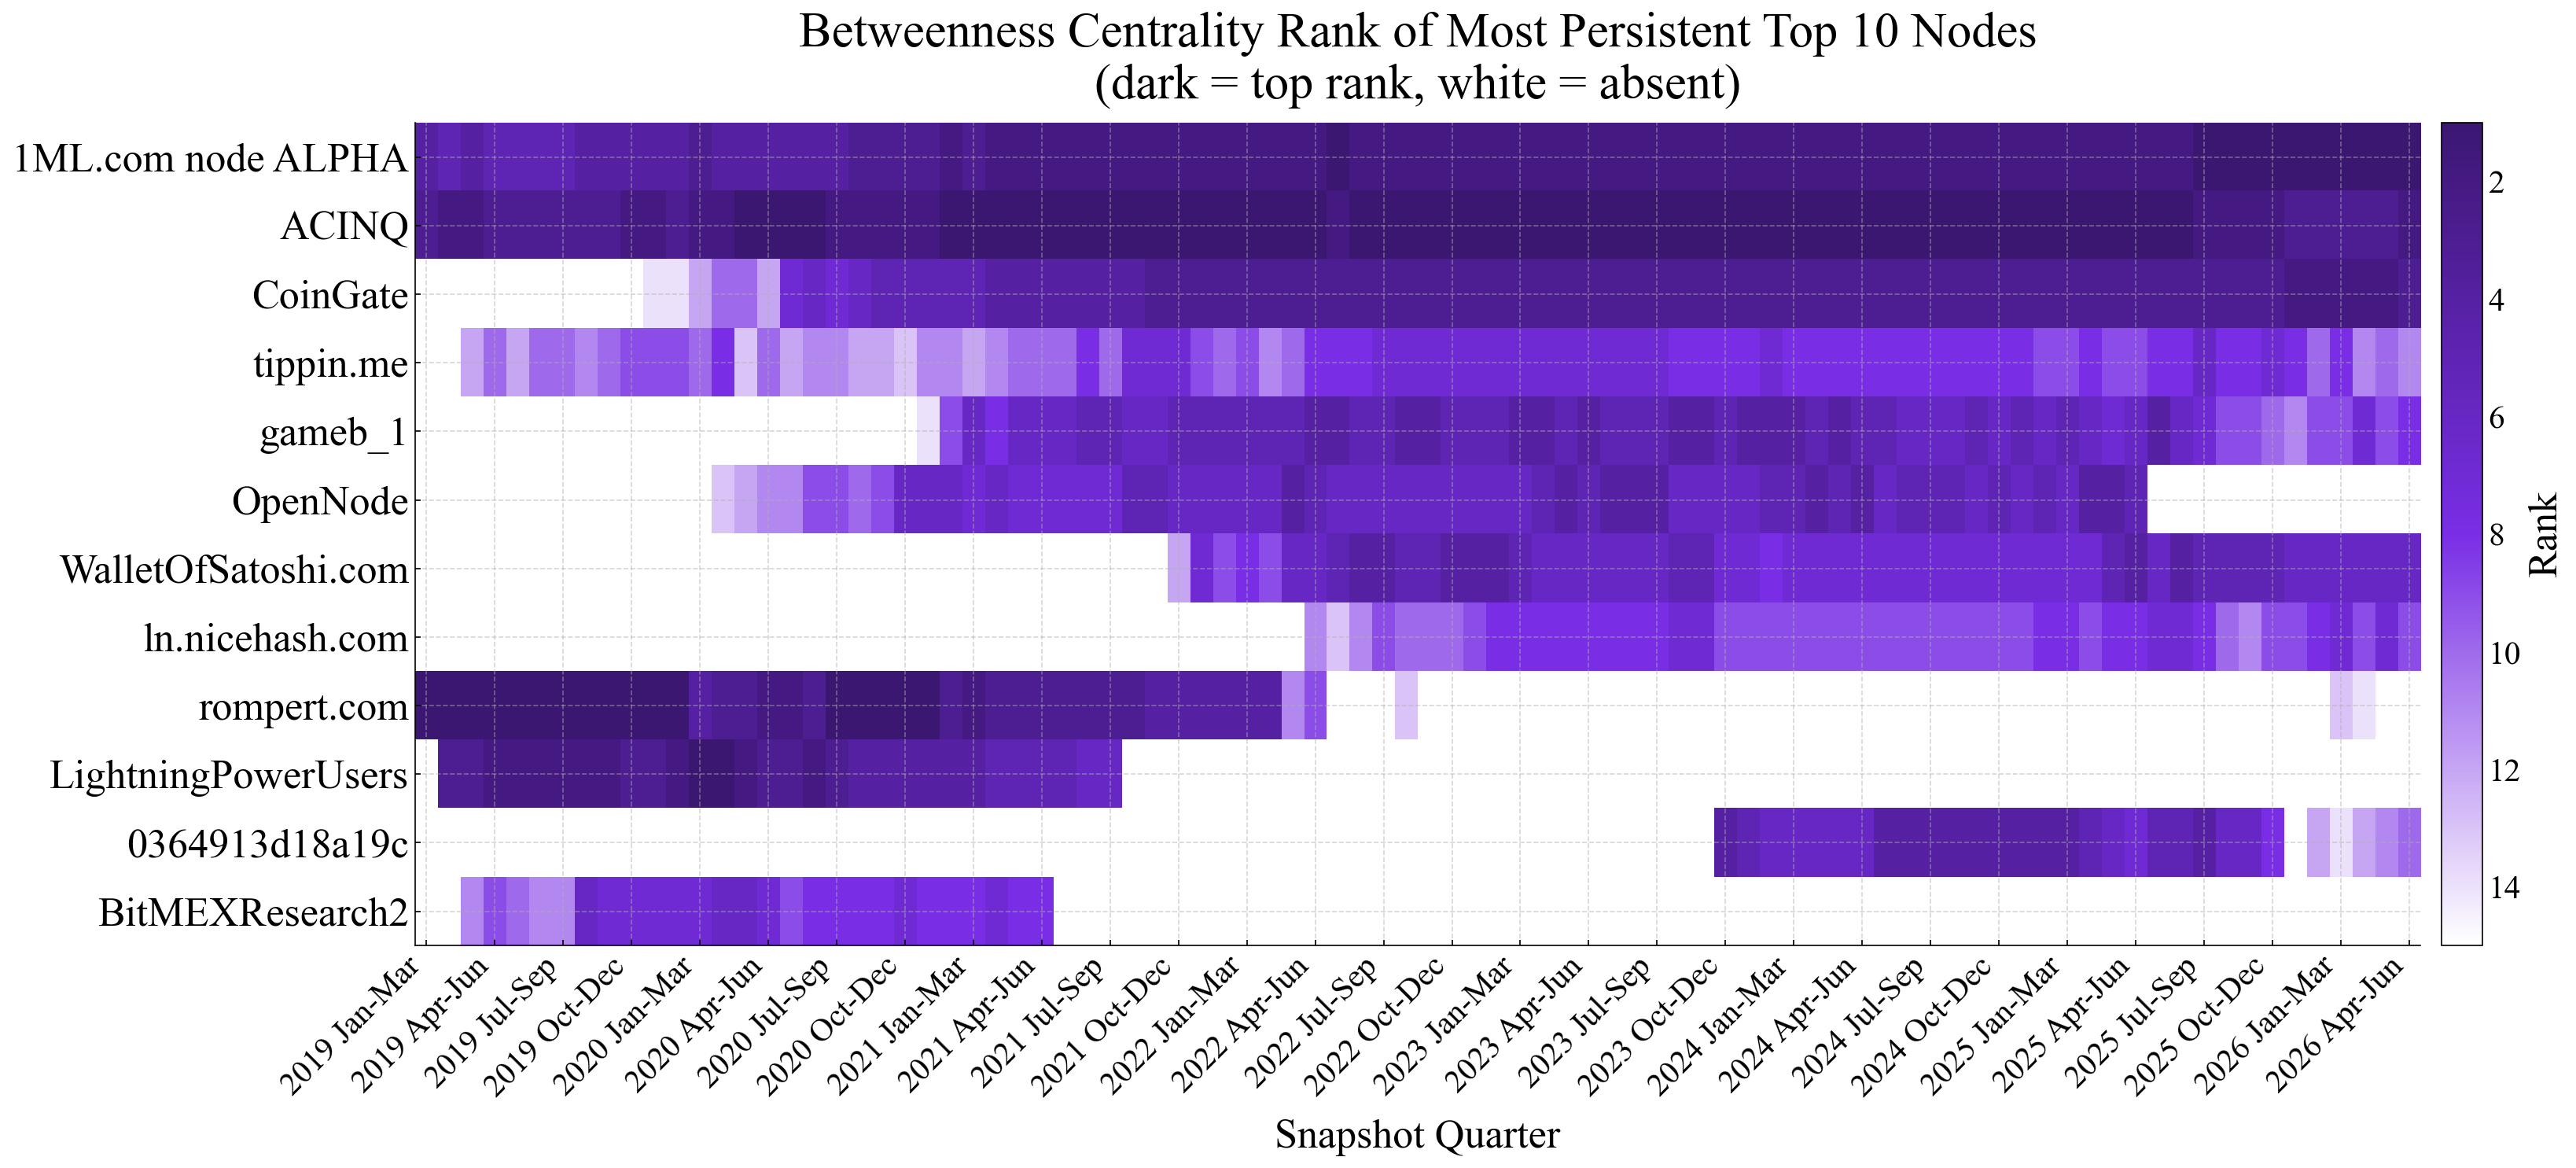

In [51]:
FONT_SCALE = 2.5 

# --- 1. Clean Alias Function ---
def clean_alias(name):
    if not isinstance(name, str):
        return str(name)
    
    name = name.encode('ascii', 'ignore').decode('ascii')
    name = name.split("[")[0] if "[" in name else name
    name = re.sub(r'\s+', ' ', name).strip()
    return name

n_persistent = 12
top10_df     = df_centrality[df_centrality["rank"] <= 10]
freq         = top10_df.groupby("node_id").size().nlargest(n_persistent)
top_nodes    = freq.index.tolist()

pivot_rows = []
for snap_date, grp in df_centrality.groupby("date"):
    row = {"date": snap_date}
    for nid in top_nodes:
        match = grp[grp["node_id"] == nid]
        row[nid] = int(match["rank"].iloc[0]) if len(match) else np.nan
    pivot_rows.append(row)

pivot = pd.DataFrame(pivot_rows).set_index("date").sort_index()

pivot.index = pd.to_datetime(pivot.index)

node_labels = {}
for nid in top_nodes:
    sub   = df_centrality[df_centrality["node_id"] == nid]["alias"].dropna()
    alias = sub.iloc[0] if len(sub) else ""
    
    alias = clean_alias(alias)
    node_labels[nid] = alias[:22] if alias else nid[:14]

pivot.columns = [node_labels[c] for c in pivot.columns]

fig, ax = plt.subplots(figsize=(max(14, len(pivot) * 0.25), 10))

data   = pivot.values.astype(float)
masked = np.ma.masked_invalid(data)

im = ax.imshow(masked.T, aspect="auto", cmap=brand_cmap, vmin=1, vmax=15, interpolation="nearest")

q_names = {1: "Jan-Mar", 2: "Apr-Jun", 3: "Jul-Sep", 4: "Oct-Dec"}
xticks = []
xticklabels = []

prev_q = None
for i, d in enumerate(pivot.index):
    curr_q = (d.year, (d.month - 1) // 3 + 1)
    
    if curr_q != prev_q:
        xticks.append(i)
        xticklabels.append(f"{d.year} {q_names[curr_q[1]]}")
        prev_q = curr_q

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, rotation=45, ha="right", fontsize=8 * FONT_SCALE)

ax.set_yticks(range(len(pivot.columns)))
ax.set_yticklabels(pivot.columns, fontsize=10 * FONT_SCALE)

ax.set_xlabel("Snapshot Quarter", fontsize=10 * FONT_SCALE, labelpad=10)
ax.set_title("Betweenness Centrality Rank of Most Persistent Top 10 Nodes\n(dark = top rank, white = absent)", 
             fontsize=12 * FONT_SCALE, pad=15)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.01)
cbar.set_label("Rank", fontsize=10 * FONT_SCALE)
cbar.ax.tick_params(labelsize=8 * FONT_SCALE) 
cbar.ax.invert_yaxis()

plt.tight_layout()

save_plot_for_latex(fig, "centrality-top-nodes-heatmap", file_path="../resources/results-final")